# **Bayesian inference – from retail to astrophysics**


# 1. Introduction to Bayesian Inference

## 1.1 What Bayesian Inference Is

Bayesian inference is a framework for learning from data by updating what one believes about unknown quantities. Instead of producing only a single estimate, it gives one a probability distribution over plausible values.

The central idea is simple:

> **prior knowledge + observed data = updated belief**

## 1.2 Why Bayesian Inference Is Used

Bayesian inference is not just a different way to compute estimates. It changes what one can ask from a model.

Key advantages:

- **Full uncertainty quantification:** one obtains a posterior distribution, not only a point estimate.
- **Credible intervals:** intervals have an intuitive interpretation, such as "there is a 95% posterior probability that the parameter lies in this range".
- **Use of prior knowledge:** expert knowledge, previous studies, historical experiments, or physical constraints can be encoded formally.
- **Sequential updating:** yesterday's posterior can become today's prior as new data arrive.
- **Small-data usefulness:** prior information can stabilise estimates when observations are limited.
- **Hierarchical modeling:** natural way to share information across groups, markets, patients, regions, or experiments.

## 1.3 Where Bayesian Inference Is Used

Bayesian methods are used in basically all fields which benefit from advanced analytics. They are especially useful when decisions require not only point estimates but also associated uncertainties, data are limited or being continually collected, or prior domain knowledge matters.

A very non-exhaustive list of examples includes:

- **Marketing:** A/B testing, marketing mix models, campaign optimization.
- **Medicine:** diagnostic testing, clinical trials, disease spread models.
- **Astrophysics:** galactic parameter estimation, gravitational-wave inference, cosmological model comparison.
- **Finance:** portfolio risk, fraud detection, algorithmic trading.
- **Retail:** elasticity of demand, price optimization, demand forecasting.
- **Neuroscience:** latent-state estimation, brain-signal decoding.

## 1.4 Bayes' Theorem

Bayesian inference is built around Bayes' theorem:

$$
p(\theta \mid D) = \frac{p(D \mid \theta)\,p(\theta)}{p(D)}
$$

where:

- $\theta$ is the unknown quantity to be inferred.
- $D$ is the observed data.
- $p(\theta)$ is the **prior**: belief held before seeing the data.
- $p(D \mid \theta)$ is the **likelihood**: how compatible the data are with a given value of $\theta$.
- $p(D)$ is the **evidence** or **marginal likelihood**: the total probability of observing the data under the model.
- $p(\theta \mid D)$ is the **posterior**: the updated belief after observing the data.

In practice, one often writes:

$$
p(\theta \mid D) \propto p(D \mid \theta)\,p(\theta)
$$

because the denominator $p(D)$ is a normalizing constant that does not depend on $\theta$.


## 1.5 Simple Example: Medical Test

Suppose a disease is rare: only **1%** of people have it.

A diagnostic test has:

- **Sensitivity:** 99%  
  If someone has the disease, the test is positive with probability 0.99.
- **Specificity:** 95%  
  If someone does not have the disease, the test is negative with probability 0.95.

Question:

> If a randomly selected person tests positive, what is the probability they actually have the disease?

Using Bayes' theorem:

$$
P(\text{Disease} \mid \text{Positive}) =
\frac{P(\text{Positive} \mid \text{Disease})P(\text{Disease})}
{P(\text{Positive})}
$$

The denominator includes true positives and false positives:

$$
P(\text{Positive}) =
P(\text{Positive} \mid \text{Disease})P(\text{Disease}) +
P(\text{Positive} \mid \text{No disease})P(\text{No disease})
$$

Substituting the numbers:

$$
P(\text{Disease} \mid \text{Positive}) =
\frac{0.99 \times 0.01}{(0.99 \times 0.01) + (0.05 \times 0.99)}
= \frac{0.0099}{0.0594}
\approx 0.167
$$

So even after a positive test, the probability of actually having the disease is about **16.7%**.

This result is often surprising, but it follows from the low base rate. When a condition is rare, false positives can outnumber true positives even for a fairly accurate test.

## 1.6 Visual Example: Updating a Conversion Rate

Now consider a continuous parameter: a conversion rate $\theta$.

A prior belief is specified that values near 50% are plausible, but extreme values near 0% or 100% are less likely:

$$
\theta \sim \mathrm{Beta}(2, 2)
$$

Then 20 trials are observed, for example 7 conversions and 13 non-conversions. With a Binomial likelihood and a Beta prior, the posterior is also Beta:

$$
\theta \mid D \sim \mathrm{Beta}(2 + 7,\ 2 + 13) = \mathrm{Beta}(9, 15)
$$

This is because a Beta prior is conjugate to a Binomial likelihood - the posterior stays in the same family, so it has a closed form:

$$
p(\theta) \propto \theta^{\alpha-1}(1-\theta)^{\beta-1} \land p(D \mid \theta) \propto \theta^{k}(1-\theta)^{n-k} \implies p(\theta \mid D) \propto \theta^{\alpha+k-1}(1-\theta)^{\beta+n-k-1},
$$

where $n$ is the number of trials and $k$ is the number of conversions.

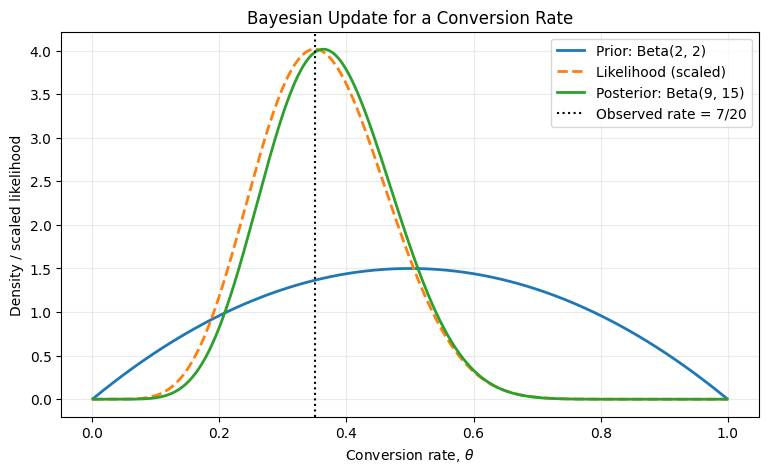

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# observed data: 7 conversions in 20 trials
conversions = 7
trials = 20
failures = trials - conversions

# weakly informative prior - Beta(2, 2) peaks at 50% without pinning theta down
prior_alpha, prior_beta = 2, 2
# conjugate update: add observed successes/failures to the prior counts
posterior_alpha = prior_alpha + conversions
posterior_beta = prior_beta + failures

theta = np.linspace(0.001, 0.999, 500)
prior_pdf = beta.pdf(theta, prior_alpha, prior_beta)
posterior_pdf = beta.pdf(theta, posterior_alpha, posterior_beta)

# likelihood is a probability mass, not a density - scale it only so it overlays
likelihood = binom.pmf(conversions, trials, theta)
likelihood_scaled = likelihood / likelihood.max() * posterior_pdf.max()

plt.figure(figsize=(9, 5))
plt.plot(theta, prior_pdf, label="Prior: Beta(2, 2)", linewidth=2)
plt.plot(theta, likelihood_scaled, label="Likelihood (scaled)", linewidth=2, linestyle="--")
plt.plot(theta, posterior_pdf, label="Posterior: Beta(9, 15)", linewidth=2)
# dotted line is the MLE 7/20 - a point estimate to contrast with the full posterior
plt.axvline(conversions / trials, color="black", linestyle=":", label="Observed rate = 7/20")
plt.title("Bayesian Update for a Conversion Rate")
plt.xlabel("Conversion rate, $\\theta$")
plt.ylabel("Density / scaled likelihood")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 1.7 Why Real-World Bayesian Models Need Approximation

The Beta-Binomial example is convenient because the posterior has a known analytical form. Most real-world Bayesian models are not that simple.

The difficult part is often the evidence term:

$$
p(D) = \int p(D \mid \theta)p(\theta)\,d\theta
$$

This integral becomes hard or impossible to compute directly when:

- $\theta$ has many dimensions.
- the likelihood is non-linear or non-conjugate.
- the model has latent variables.
- parameters are arranged hierarchically, such as customers inside regions inside markets.
- the posterior has correlations, skewness, or multiple modes.

In these cases, the posterior usually cannot be written down in a neat closed form. Instead, it is approximated.


## 1.8 Markov Chains: The Core Idea

A **Markov chain** is a sequence of random states:

$$
X_1, X_2, X_3, \ldots
$$

with one key property:

> The next state depends only on the current state, not on the full history.

Formally:

$$
P(X_{t+1} \mid X_t, X_{t-1}, \ldots, X_1) = P(X_{t+1} \mid X_t)
$$

This is called the **Markov property**.

Why does this help? Some Markov chains have a **stationary distribution**: after running long enough, the chain visits different regions in stable long-run proportions. If the chain is designed carefully, that stationary distribution can be the Bayesian posterior of interest.


## 1.9 MCMC: Sampling From the Posterior

**Markov Chain Monte Carlo (MCMC)** methods build a Markov chain whose stationary distribution is the posterior distribution:

$$
p(\theta \mid D)
$$

After the chain has run for long enough, its draws can be treated as approximate samples from the posterior. Those samples can then be used to estimate means, credible intervals, posterior predictive distributions, probabilities of business outcomes, and more.

A classic MCMC algorithm is **Metropolis-Hastings**:

1. Start from an initial value of $\theta$.
2. Propose a nearby candidate value $\theta'$.
3. Compare the posterior density at $\theta'$ with the posterior density at the current $\theta$.
4. Accept or reject the candidate with a probability that preserves the target posterior distribution.
5. Repeat many times.

The powerful trick is that the acceptance decision only needs the posterior up to proportionality:

$$
p(\theta \mid D) \propto p(D \mid \theta)p(\theta)
$$

So MCMC can avoid computing the difficult evidence term $p(D)$ directly.


## 1.10 Tiny MCMC Demo

To keep the example transparent, the same conversion-rate problem as before is tackled. To approximate the posterior, Metropolis-Hastings algorithm is used.


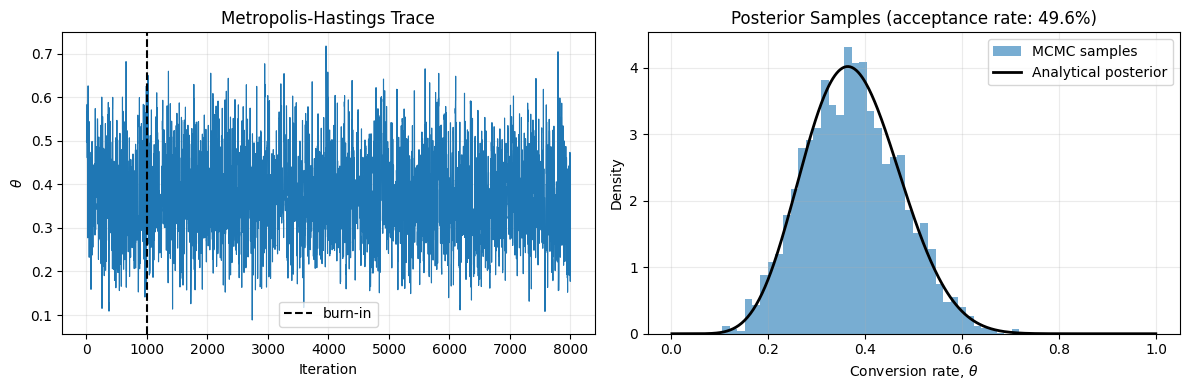

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

rng = np.random.default_rng(42)

# reuse the 7/20 data and weakly informative Beta(2, 2) prior
conversions = 7
trials = 20
failures = trials - conversions
prior_alpha, prior_beta = 2, 2
posterior_alpha = prior_alpha + conversions
posterior_beta = prior_beta + failures

def log_target(theta):
    """Log posterior density up to an additive constant."""
    # conversion rate lives in (0, 1) - reject proposals outside the range
    if theta <= 0 or theta >= 1:
        return -np.inf
    # log of the Beta kernel; skip the constant because MH only needs ratios
    return (
        (prior_alpha + conversions - 1) * np.log(theta)
        + (prior_beta + failures - 1) * np.log(1 - theta)
    )

n_samples = 8_000
proposal_sd = 0.2 # standard deviation of the proposal
samples = np.empty(n_samples)
# start near the prior mode so the chain does not begin at the boundary
samples[0] = 0.5
accepted = 0

for i in range(1, n_samples):
    current = samples[i - 1]
    # Gaussian random-walk proposal centered on the current state
    proposal = rng.normal(current, proposal_sd)
    # log-ratio accept/reject
    log_acceptance_ratio = log_target(proposal) - log_target(current)

    if np.log(rng.uniform()) < log_acceptance_ratio:
        samples[i] = proposal
        accepted += 1
    else:
        # on reject, stay put - the chain still advances one iteration
        samples[i] = current

# discard burn-in so the plotted histogram is not mixed with the start-up path
burn_in = 1_000
posterior_samples = samples[burn_in:]
# acceptance rate is a tuning check
acceptance_rate = accepted / (n_samples - 1)

theta_grid = np.linspace(0.001, 0.999, 500)
true_posterior = beta.pdf(theta_grid, posterior_alpha, posterior_beta)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left panel: trace of the chain (including burn-in)
axes[0].plot(samples, linewidth=0.8)
axes[0].axvline(burn_in, color="black", linestyle="--", label="burn-in")
axes[0].set_title("Metropolis-Hastings Trace")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("$\\theta$")
axes[0].legend()
axes[0].grid(alpha=0.25)

# right panel: histogram of post-burn-in draws vs analytical Beta(9, 15)
axes[1].hist(posterior_samples, bins=40, density=True, alpha=0.6, label="MCMC samples")
axes[1].plot(theta_grid, true_posterior, color="black", linewidth=2, label="Analytical posterior")
axes[1].set_title(f"Posterior Samples (acceptance rate: {acceptance_rate:.1%})")
axes[1].set_xlabel("Conversion rate, $\\theta$")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# 2. Bayesian Inference in the Wild: The Milky Way Rotation Curve

## 2.1 Probing Mass with Circular Velocity

The circular velocity of an object at a given galactocentric radius probes the gravitational field at that radius. If one can construct a rotation curve — circular velocities measured at many radii — the underlying mass distribution can be inferred. The link between kinematics and mass is achieved using the fact that the gravitational force plays the role of the centripetal force.

### High school recap

For uniform circular motion, a body of mass $m$ moving at speed $v$ on a circle of radius $R$ has centripetal acceleration

$$
a = \frac{v^2}{R}.
$$

Newton's law of gravitation gives the attractive force between two point masses $M$ and $m$ separated by distance $r$:

$$
F = \frac{G M m}{r^2}.
$$

For a circular orbit around a single point mass $M$, equating the gravitational force to the centripetal requirement $F = m a$ gives

$$
\frac{v^2}{R} = \frac{G M}{R^2}
\quad\Rightarrow\quad
v^2 = \frac{G M}{R}.
$$

This is the familiar Keplerian result: the orbital speed in gravitational field generated by a single point mass falls as $v \propto R^{-1/2}$. Measuring $v$ at radius $R$ therefore reveals how massive the single point source is. 

### Early undergrad extension

For an extended, **spherically symmetric** mass distribution, the same force balance for an object on a roughly circular orbit gives

$$
\frac{v^2}{R} = \frac{G\,M(<R)}{R^2},
$$

Rearranging,

$$
v(R) = \sqrt{\frac{G\,M(<R)}{R}},
$$

where $M(<R)$ is the **enclosed mass** — all the mass interior to a sphere of radius $R$.

A key result from Newtonian gravity (the shell theorem) is that for a spherically symmetric distribution (depending on radius alone), **only the mass inside radius $R$ affects the orbit**. Mass in shells at larger radii exerts no net pull on the object. So each measurement of $v$ at a given $R$ is really a measurement of how much mass sits within that radius. By observing $v(R)$ at many radii, $M(<R)$ is mapped out.

### Late undergrad extension

Real astrophysical mass distributions are rarely spherically symmetric, so a more general formulation is needed. For an **axisymmetric** (symmetrical around the rotation axis) mass distribution, a circular orbit in the midplane ($z = 0$) satisfies

$$
v_c^2(R) = R \left.\frac{\partial \Phi}{\partial R}\right|_{z=0},
$$

where $\Phi$ is the gravitational potential, related to the mass density $\rho$ by Poisson's equation

$$
\nabla^2 \Phi = 4\pi G \rho.
$$

For example, for a **thin exponential disc**, with surface density

$$
\Sigma(R) = \Sigma_0 \exp\!\left(-\frac{R}{R_d}\right),
$$

the potential must be obtained by solving Poisson's equation, and $v_c(R)$ does not follow $\sqrt{G M(<R)/R}$. For a disc of total mass $M_d$ and scale length $R_d$, the Freeman (1970) result is

$$
v_{\rm disc}^2(R) = \frac{2 G M_d}{R_d} \left(\frac{R}{2 R_d}\right)^2 \left[ I_0\!\left(\frac{R}{2 R_d}\right) K_0\!\left(\frac{R}{2 R_d}\right) - I_1\!\left(\frac{R}{2 R_d}\right) K_1\!\left(\frac{R}{2 R_d}\right) \right],
$$

where $I_n$ and $K_n$ are modified Bessel functions of the first and second kind.

When the total potential is a sum of several components, $\Phi = \sum_i \Phi_i$, the corresponding circular velocities add in quadrature:

$$
v_{\rm tot}^2(R) = \sum_i v_i^2(R).
$$

## 2.2 Rotation Curves of Disc Galaxies

The disc result is particularly relevant, because many large galaxies, including the Milky Way, are **disc galaxies**: flattened, rotating systems with a central bulge, a thin stellar disc, and a more extended diffuse halo. Stars in the disc move on nearly circular orbits around the Galactic centre, making their velocities a direct probe of the gravitational field. Measuring $v_c(R)$ at many radii in such systems yields a **rotation curve** — the profile of circular speeds needed to sustain disc orbits. If the luminous disc and bulge were the only gravitating components, one would expect $v_c(R)$ to decline at large radii, in the same Keplerian fashion as in §2.1, once most of the visible mass has been enclosed. For external spiral galaxies, however, Vera Rubin and collaborators found in the 1970s and 1980s that $v_c(R)$ stays nearly **flat** out to large radii — a pattern repeated across galaxy after galaxy (Rubin et al. 1980). A flat rotation curve requires enclosed mass to keep growing,

$$
M(<R) \propto R,
$$

even where little luminous matter is visible. This was among the first strong, direct evidence that galaxies are embedded in extended **dark matter halos** — massive structures which do not interact with light, but whose gravity shapes galactic dynamics.

![Rotation curves of external galaxies](figures\ExRCs.png)

*Rotation curves of SB (full lines) and SBb (dashed lines) galaxies (Sofue 2016).*

For the **Milky Way**, inferring the rotation curve is observationally harder because of our observing position within the Galactic disc. Each tracer must yield a reliable distance and full 3D velocity in a Galactocentric frame, with corrections for the Sun's motion and non-circular motions. For decades, the Milky Way rotation curve was widely treated as **approximately flat** over much of the disc, analogous to other spiral galaxies, implying a substantial dark-matter halo. Total mass estimates from a range of tracers and methods often clustered around $\sim 10^{12}\,M_\odot$, though the precise values depend on radius and modelling assumptions (Sawala et al. 2025). Recently, this picture has been challenged. Wang et al. (2023), Jiao et al. (2023), and Ou et al. (2024) found Galactic rotation curves that **decline at large radii** (out to $\sim 30$ kpc) and inferred **systematically lower Milky Way masses** than many earlier estimates. This is the main motivation for this analysis.

## 2.3 Rotation-Curve Tracers

A variety of objects have been used for the purpose of constructing the Milky Way rotation curve, including:

- interstellar gas traced by HI and CO line emission,
- radio masers in star-forming regions,
- **classical Cepheid variables**,
- red-clump giants, RR Lyrae stars, and luminous red giants on the upper giant branch.

Different tracers probe different stellar populations, age ranges, and distance regimes. This work uses classical Cepheids.

### What classical Cepheids are

Classical Cepheids are young, luminous stars that pulsate radially with periods of order days to weeks. They trace the **young thin disc** and, because they are intrinsically bright, can be observed to large heliocentric distances.

### Why they are useful for rotation-curve work

Cepheid pulsations follow well-studied **period–luminosity relations** (Leavitt 1908), which enable precise distance determination. Combined with measured radial velocities and proper motions, they yield the 6D phase-space information needed to place a star on the rotation curve. As disc objects on near-circular orbits, they are direct probes of $v_c(R)$ at their galactocentric radii.

![Cepheid period-luminosity relation](figures\PLR.png)

*Period-luminosity relation of the classical Cepheid variables (Storm et al. 2011).*

## 2.4 Why an Accurate Rotation Curve Matters

* It probes the **mass distribution of the Galaxy and its components**, constraining some of its most fundamental parameters. 

* It enables one to estimate the **local dark-matter density** $\rho_{\mathrm{DM},\odot}$, which is essential for many studies on the nature of dark matter - one of the biggest unknowns in physics.

* It provides an independent constraint on the **circular velocity of the Sun**.


## 2.5 The Analysis: An Independent Test with Cepheids

This section applies the Bayesian framework to infer the Milky Way dark-matter halo parameters from a rotation curve traced by classical Cepheids. Two main data sources are used: **distances** are taken from the Cepheid catalog of Skowron et al. (2025), **3D velocities** are derived from **Gaia DR3**. Gaia is a 2013 ESA space observatory, which vastly increased the number of stars with measured 3D velocities and catalogued a total of almost 2 billion stars (Gaia Collaboration et al. 2016). For brevity in this analysis, a **fixed baryonic mass model** is adopted — the B2 model from de Salas et al. (2019) — and only the **dark-matter halo**, parametrised as an **Einasto profile** with normalization $M_{\rm nor}$, scale radius $r_s$, and shape $\alpha$, plus an intrinsic scatter term $\epsilon$, is inferred.

The posterior is sampled with **`emcee`** — an implementation of Goodman and Weare's affine-invariant ensemble MCMC sampler (Foreman-Mackey et al. 2013). Unlike full probabilistic-programming frameworks such as Stan or PyMC — which specify models in a dedicated language and handle much of the inference pipeline automatically — **`emcee` is a lightweight, sampler-focused library**: the user supplies a Python function that returns the log-posterior (prior plus likelihood), and the package returns MCMC chains. It was developed primarily for astrophysics and other fields where the physical model is already coded by hand and the main need is efficient posterior exploration. 

Its core algorithm is an **ensemble sampler**: instead of a single Markov Chain, the algorithm uses an ensemble of walkers. In the default stretch move, a walker proposes a new position by referencing another walker in the ensemble and stretching or contracting the vector connecting them. Because these proposals are constructed using the relative geometry of the ensemble, the resulting sampler is affine invariant: its behavior is largely unchanged under linear rescalings, rotations, or shears of the parameter space. As a result, **`emcee`** is often much more robust than traditional random-walk Metropolis-Hastings methods when sampling highly correlated or poorly scaled posterior distributions.

In [3]:
import numpy as np
import pandas as pd
import emcee
import corner
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.special import gamma, gammainc, iv, kn
from pathlib import Path

In [4]:
# load and merge the main rotation-curve dataset and Gaia quality-check table
data_dir = Path("data")
df = pd.read_csv(data_dir / "galactocentric_distance_and_velocities.csv")
checks_df = pd.read_csv(data_dir / "cepheid_checks_gaia.csv")
checks_df["gaia-id"] = "gaia" + checks_df["source_id"].astype(str)
df = df.merge(
    checks_df[["gaia-id", "ruwe", "astrometric_excess_noise", "duplicated_source"]],
    on="gaia-id",
    how="left",
).reset_index(drop=True)

# apply Gaia quality cuts and remove velocity outliers
df = df[
    (df["ruwe"] <= 1.4) & (df["astrometric_excess_noise"] <= 2) & (~df["duplicated_source"])
].reset_index(drop=True)
df = df.drop(columns=["ruwe", "astrometric_excess_noise", "duplicated_source"])
df = df[(df["V_mean"] < 359.55) & (df["V_mean"] > 77.95)]

R = df["R_mean"].to_numpy() / 1000  # pc -> kpc conversion
Rerr = df["R_std"].to_numpy() / 1000
V = df["V_mean"].to_numpy()
Verr = df["V_std"].to_numpy()

print(f"Loaded {len(df)} Cepheid tracers for the rotation-curve fit.")

df.head()

Loaded 1846 Cepheid tracers for the rotation-curve fit.


,gaia-id,R_mean,R_std,U_mean,V_mean,W_mean,U_std,V_std,W_std,cov_UU,cov_UV,cov_UW,cov_VV,cov_VW,cov_WW
0,gaia429385923752386944,10019.693331,95.775420,30.920886,212.548890,-5.864712,2.344208,3.016875,0.674161,5.495310,-6.333109,0.451715,9.101533,-1.292208,0.454493
1,gaia432188922485600384,13885.543289,276.818816,7.639678,231.572726,0.074930,3.754192,3.744038,1.138355,14.093954,-10.360694,-0.445188,14.017822,0.218502,1.295852
2,gaia430052537038350976,16166.423694,398.028640,4.485822,225.791206,1.271066,3.888945,3.821516,0.922856,15.123892,-10.447932,0.182278,14.603985,-0.613258,0.851663
3,gaia429890595286480384,10775.524642,127.477214,17.542522,225.367223,5.152101,2.402121,2.876659,0.297780,5.770187,-6.130564,0.156421,8.275169,-0.280518,0.088673
4,gaia432291280141114624,12225.747696,196.980894,-0.486601,215.980371,-11.304208,2.542104,2.463165,1.204644,6.462295,-5.104337,0.558158,6.067180,-0.688533,1.451168


### The physical model

The total circular velocity at each galactocentric radius is built from a fixed baryonic component and a flexible dark-matter halo:

$$
v_{\rm tot}^2(R) = v_{\rm DM}^2(R) + v_{\rm bar}^2(R).
$$

#### Baryonic component

The squared baryonic contribution is represented as the sum of a spherical bulge and five axisymmetric, infinitesimally thin exponential disk-like components:

$$
v_{\rm bar}^2 = v_{\rm bulge}^2 + v_{\rm disc}^2 + v_{\rm warm\,dust}^2 + v_{\rm cold\,dust}^2 + v_{\rm HI}^2 + v_{\rm H_2}^2.
$$

The bulge is modeled with a Hernquist (1990) profile:

$$
v_{\rm bulge}^2(r) = \frac{G\,M_b\,r}{(r + r_b)^2},
$$

with adopted mass $M_b = 1.55 \times 10^{10}\,M_\odot$ and scale radius $r_b = 0.7$ kpc.

The stellar disc, warm and cold dust, and atomic ($HI$) and molecular ($H_2$) gas are each treated as Freeman (1970) exponential disks with surface density

$$
\Sigma(r) = \frac{M_d}{2\pi r_d^2}\,\exp\!\left(-\frac{r}{r_d}\right).
$$

The adopted B2 parameters from de Salas et al. (2019) are:

| Component | $M_d$ [$M_\odot$] | $r_d$ [kpc] |
|-----------|-------------------|-------------|
| Stellar disc | $3.65 \times 10^{10}$ | 2.35 |
| Warm dust | $2.2 \times 10^{5}$ | 3.3 |
| Cold dust | $7 \times 10^{7}$ | 5.0 |
| $HI$ | $8.2 \times 10^{9}$ | 18.24 |
| $H_2$ | $1.3 \times 10^{9}$ | 2.57 |

#### Dark-matter halo (Einasto)

The halo is parametrised as a spherical **Einasto** (1965) profile with density

$$
\rho(r)=\frac{M_{\rm nor}}{4\pi r_s^3}
\exp\!\left[-\left(\frac{r}{r_s}\right)^\alpha\right],
$$

where $M_{\rm nor}$ is a mass normalisation, $r_s$ is the scale radius, and $\alpha$
controls the radial curvature of the density slope (smaller $\alpha$ corresponds to a
more gradually varying logarithmic slope).

The enclosed mass has the analytic form

$$
M(<r)
=
\frac{M_{\rm nor}}{\alpha}
\gamma\!\left(
\frac{3}{\alpha},
\left(\frac{r}{r_s}\right)^\alpha
\right),
$$

where $\gamma$ is the lower incomplete gamma function. Only the halo parameters
$M_{\rm nor}$, $r_s$, and $\alpha$ are inferred (together with an intrinsic scatter term
$\epsilon$) in the statistical model below.

In [5]:
G = 4.300917270e-6  # (km/s)^2 kpc / Msun

def disk_velocity_contribution(M_d, r_d, r):
    """Squared circular velocity from a Freeman exponential disk."""
    # radius in units of two disk scale lengths - the argument of the Bessel functions
    x = r / (2 * r_d)
    # modified Bessel functions of the first (I) and second (K) kind
    I_0 = iv(0, x)
    I_1 = iv(1, x)
    K_0 = kn(0, x)
    K_1 = kn(1, x)
    # Freeman's Bessel combination - encodes the flattened (non-spherical) mass geometry
    B = I_0 * K_0 - I_1 * K_1
    return ((G * M_d) / r_d) * 2 * x**2 * B

def baryon_velocity_contribution(r):
    """Total squared baryonic circular velocity."""
    v_bulge_squared = G * 1.55e10 * r / (r + 0.7) ** 2 # central bulge
    v_disk_squared = disk_velocity_contribution(3.65e10, 2.35, r) # stellar disk
    v_warm_dust_squared = disk_velocity_contribution(2.2e5, 3.3, r) # warm interstellar dust
    v_cold_dust_squared = disk_velocity_contribution(7e7, 5.0, r) # cold interstellar dust
    v_h1_squared = disk_velocity_contribution(8.2e9, 18.24, r) # atomic hydrogen
    v_h2_squared = disk_velocity_contribution(1.3e9, 2.57, r) # molecular hydrogen
    # sum of squred velocities
    return (
        v_bulge_squared
        + v_disk_squared
        + v_warm_dust_squared
        + v_cold_dust_squared
        + v_h1_squared
        + v_h2_squared
    )

# the baryons are fixed, so precompute them once on a fine radial grid (0.1 pc spacing)
# and look them up during sampling instead of re-evaluating Bessel functions per step
r_arr = np.linspace(1e-4, 30, 30 * 10000)
v2_bar_arr = baryon_velocity_contribution(r_arr)

def enclosed_einasto_mass(M_nor, r_s, alpha, r):
    """Enclosed mass for a spherical Einasto halo."""
    # integrating the Einasto density gives a lower incomplete gamma function
    upper_integration_limit = (r / r_s) ** alpha
    return (M_nor / alpha) * gamma(3 / alpha) * gammainc(3 / alpha, upper_integration_limit)

def model_velocity(M_nor, r_s, alpha, r):
    """Total circular velocity from Einasto DM + fixed baryons."""
    mass_enclosed_dm = enclosed_einasto_mass(M_nor, r_s, alpha, r)
    v_dm_squared = G * mass_enclosed_dm / r
    # map radius onto the precomputed baryon grid
    idx = r.round(4) * 10000 - 1
    idx = idx.astype(int)
    v_baryon_squared = v2_bar_arr[idx]
    # total velocity is the root of the summed squares
    return np.sqrt(v_dm_squared + v_baryon_squared)

def velocity_derivative_wrt_radius(M_nor, r_s, alpha, r, rel_eps=1e-4):
    """Numerical dv/dR for uncertainty propagation."""
    # relative step, floored at 1 kpc scale so small radii don't get a tiny h
    h = rel_eps * np.maximum(r, 1.0)
    # central finite-difference approximation
    return (
        model_velocity(M_nor, r_s, alpha, r + h)
        - model_velocity(M_nor, r_s, alpha, r - h)
    ) / (2 * h)

### The Bayesian model

Four halo parameters are fitted:

$$
\theta = (\log_{10} M_{\rm nor},\ r_s,\ \alpha,\ \epsilon)
$$

**Priors:** Flat priors are placed on $\log_{10} M_{\rm nor} \in [10, 14]$, $r_s \in [0.1, 20]$ kpc, and $\alpha \in [0.05, 4.0]$. For the intrinsic scatter a weakly informative Gaussian prior centred on a physically sensible scale for disc peculiar velocities is used:

$$
\epsilon \sim \mathcal{N}(20,\ 10^2)\ \mathrm{km\,s^{-1}}
$$

with the additional requirement $\epsilon > 0$.

**Likelihood:** At each observed radius a Gaussian residual in circular velocity is assumed. The total variance combines the reported velocity uncertainty, a propagated contribution from the radial distance error, and an intrinsic scatter term $\epsilon$ that accounts for non-circular motions:

$$
\sigma_{\rm tot}^2 = \sigma_v^2 + \left(\frac{dv}{dR}\right)^2 \sigma_R^2 + \epsilon^2
$$

The $N$ Cepheid measurements are treated as conditionally independent given $\theta$. The log-likelihood is evaluated as

$$
\log p(D \mid \theta)
= -\frac{1}{2} \sum_{i=1}^{N}
\left[
\frac{\bigl(V_i - v_{\rm model}(R_i;\,\theta)\bigr)^2}{\sigma_{{\rm tot},i}^2}
+ \log\!\bigl(2\pi\,\sigma_{{\rm tot},i}^2\bigr)
\right],
$$

where $V_i$ and $R_i$ are the observed circular velocity and galactocentric radius of tracer $i$, and $v_{\rm model}(R_i;\,\theta)$ is the predicted velocity from the Einasto halo plus fixed baryons. The first summand is the usual $\chi^2$-like penalty on the velocity residual; the second is the Gaussian normalization term that ensures a proper density.

**Posterior:**

$$
\log p(\theta \mid D) = \log p(\theta) + \log p(D \mid \theta) + \mathrm{const.}
$$


In [6]:
eps_prior_mu, eps_prior_sigma = 20.0, 100.0 # km/s

def log_prior(params):
    """Log-prior density for the Einasto halo parameters."""
    log_M_nor, r_s, alpha, eps = params
    # flat priors - anything outside the bounds gets zero probability
    if not (10.0 <= log_M_nor <= 14.0):
        return -np.inf
    if not (0.1 <= r_s <= 20.0):
        return -np.inf
    if not (0.05 <= alpha <= 4.0):
        return -np.inf
    # intrinsic scatter must be positive to be a valid standard deviation
    if eps <= 0:
        return -np.inf
    # Gaussian prior on eps - weakly informative, centred on the expected scatter
    return (
        -0.5 * ((eps - eps_prior_mu) / eps_prior_sigma) ** 2
        - np.log(eps_prior_sigma * np.sqrt(2 * np.pi))
    )

def log_likelihood(params, x, sigma_x, y, sigma_y):
    """Gaussian log-likelihood for the rotation-curve fit."""
    log_M_nor, r_s, alpha, eps = params
    M_nor = 10 ** log_M_nor # sampled in log space - convert back to linear mass
    sigma_tot_squared = (
        sigma_y ** 2
        + velocity_derivative_wrt_radius(M_nor, r_s, alpha, x) ** 2 * sigma_x ** 2
        + eps ** 2
    ) # total variance
    # difference between the observed and predicted circular velocity of each tracer
    residuals = y - model_velocity(M_nor, r_s, alpha, x)
    # chi-square term plus the log-normalisation
    return -0.5 * np.sum(
        residuals ** 2 / sigma_tot_squared + np.log(2 * np.pi * sigma_tot_squared)
    )

def log_probability(params, x, sigma_x, y, sigma_y):
    """Unnormalized log-posterior (prior + likelihood) for emcee."""
    lp = log_prior(params)
    # outside the prior bounds the likelihood is never evaluated
    if not np.isfinite(lp):
        return -np.inf
    # log posterior up to a constant
    return lp + log_likelihood(params, x, sigma_x, y, sigma_y)

In [7]:
# define MCMC sampling parameters and initial parameter values
ndim, nwalkers = 4, 10
M_nor0, r_s0, alpha0, eps0 = 6e10, 4.0, 1.0, 20.0

# add small jitter so the walkers aren't identical
rng = np.random.default_rng(42)
p0 = np.column_stack([
    np.log10(M_nor0) + 0.1 * rng.standard_normal(nwalkers),
    r_s0 + 0.2 * rng.standard_normal(nwalkers),
    alpha0 + 0.1 * rng.standard_normal(nwalkers),
    eps0 + rng.standard_normal(nwalkers),
])

In [8]:
# h5 file holding the chains, log-posteriors and some metadata
chain_path = Path("chains/rotation_curve_mcmc.h5")
chain_path.parent.mkdir(exist_ok=True)
nsteps = 150_000

# emcee only runs when there is no saved posterior on disk
if not chain_path.exists():
    # run the sampling and save to disk
    backend = emcee.backends.HDFBackend(str(chain_path))
    backend.reset(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_probability,
        args=(R, Rerr, V, Verr),
        backend=backend,
    )
    sampler.run_mcmc(p0, nsteps, progress=True)
    print(f"Saved MCMC chain to {chain_path}")
else:
    print(f"Chain already exists at {chain_path}; skipping sampling.")

# reload the saved chain
sampler = emcee.backends.HDFBackend(str(chain_path), read_only=True)

100%|██████████| 150000/150000 [1:11:46<00:00, 34.83it/s]

Saved MCMC chain to chains\rotation_curve_mcmc.h5


### Posterior summary

The cells below turn the saved chain into results. Three figures are created: a corner plot with the 1D marginals and 2D parameter correlations, a trace plot with one panel per parameter and all walkers overlaid (the dashed line marks the burn-in cut), and the rotation curve, comparing the Cepheid measurements with the median posterior model split into dark-matter (Einasto) and baryonic contributions.

In [9]:
def q16_50_84(x):
    """Asymmetric 16/50/84 credible intervals (median with lower/upper offsets)."""
    p16, p50, p84 = np.percentile(x, [16, 50, 84])
    return p50, p50 - p16, p84 - p50

# estimate burn-in from autocorrelation time (emcee rule of thumb: 2 tau)
tau = sampler.get_autocorr_time(quiet=True)
nburn = int(2 * np.max(tau))
print(f"Burn-in: {nburn} steps")

# flatten post-burn-in samples and convert log10 M_nor back to linear mass
flat = sampler.get_chain(discard=nburn, flat=True)
log_M_nor_s, r_s_s, alpha_s, eps_s = flat.T
M_nor_s = 10 ** log_M_nor_s

M_nor_med, M_nor_lo, M_nor_hi = q16_50_84(M_nor_s)
r_s_med, r_s_lo, r_s_hi = q16_50_84(r_s_s)
alpha_med, alpha_lo, alpha_hi = q16_50_84(alpha_s)
eps_med, eps_lo, eps_hi = q16_50_84(eps_s)

# print posterior medians and 1-sigma credible intervals
print(f"M_nor = {M_nor_med:.3e} +{M_nor_hi:.3e}/-{M_nor_lo:.3e} Msun")
print(f"r_s   = {r_s_med:.3f} +{r_s_hi:.3f}/-{r_s_lo:.3f} kpc")
print(f"alpha = {alpha_med:.3f} +{alpha_hi:.3f}/-{alpha_lo:.3f}")
print(f"eps   = {eps_med:.2f} +{eps_hi:.2f}/-{eps_lo:.2f} km/s")

Burn-in: 303 steps
M_nor = 2.514e+11 +2.393e+10/-2.721e+10 Msun
r_s   = 9.265 +0.529/-0.596 kpc
alpha = 1.582 +0.152/-0.143
eps   = 14.62 +0.27/-0.27 km/s


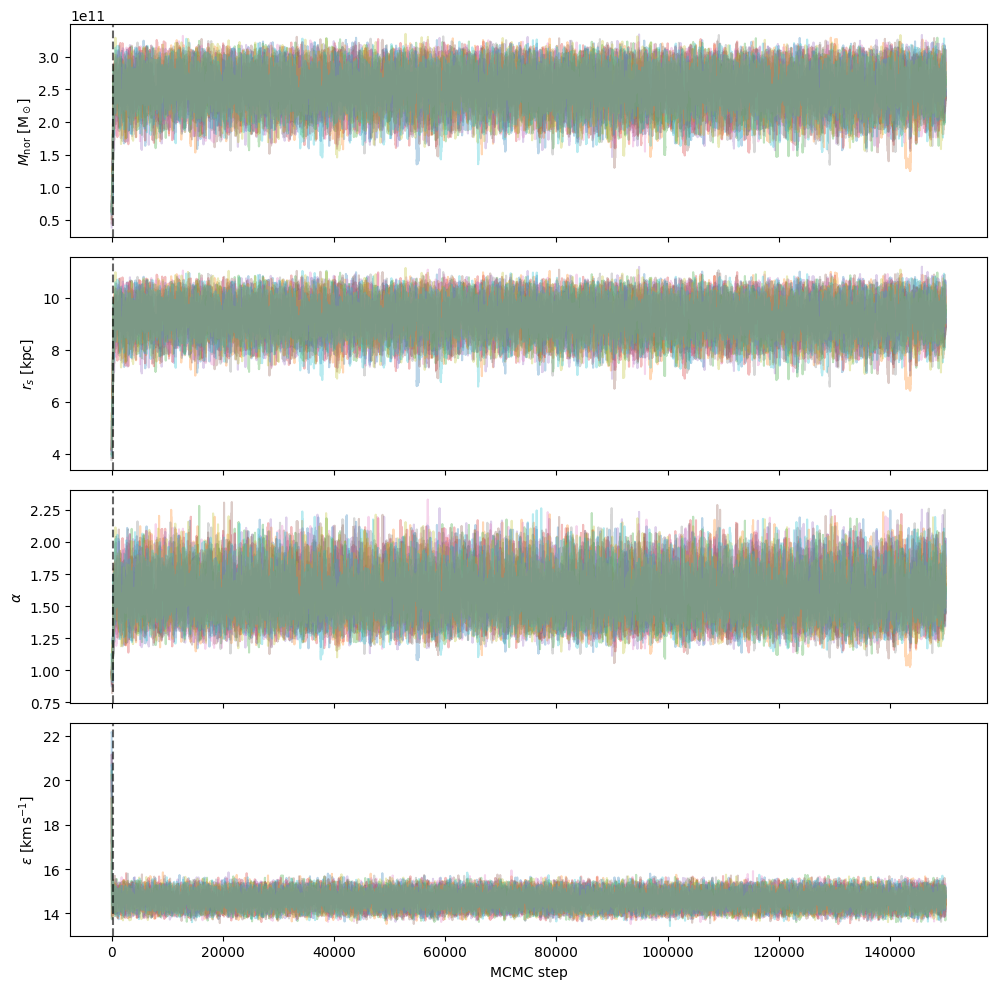

In [13]:
# full unflattened chain, shape (n_steps, n_walkers, n_params), burn-in included
chain = sampler.get_chain()

log_M_nor_tr = chain[:, :, 0]
r_s_tr = chain[:, :, 1]
alpha_tr = chain[:, :, 2]
eps_tr = chain[:, :, 3]

traces = [10 ** log_M_nor_tr, r_s_tr, alpha_tr, eps_tr]
trace_labels = [
    r"$M_{\mathrm{nor}}\ [\mathrm{M_\odot}]$",
    r"$r_s\ [\mathrm{kpc}]$",
    r"$\alpha$",
    r"$\epsilon\ [\mathrm{km\,s^{-1}}]$",
]

# trace plot: one panel per parameter, all walkers overlaid
fig, axes = plt.subplots(len(traces), 1, figsize=(10, 10), sharex=True)

for k, (lab, tr) in enumerate(zip(trace_labels, traces)):
    ax = axes[k]
    ax.plot(tr, alpha=0.3)
    ax.set_ylabel(lab)
    if nburn > 0:
        # vertical line marks the burn-in cutoff used above
        ax.axvline(nburn, ls="--", c="k", alpha=0.6)

axes[-1].set_xlabel("MCMC step")
plt.tight_layout()
plt.show()

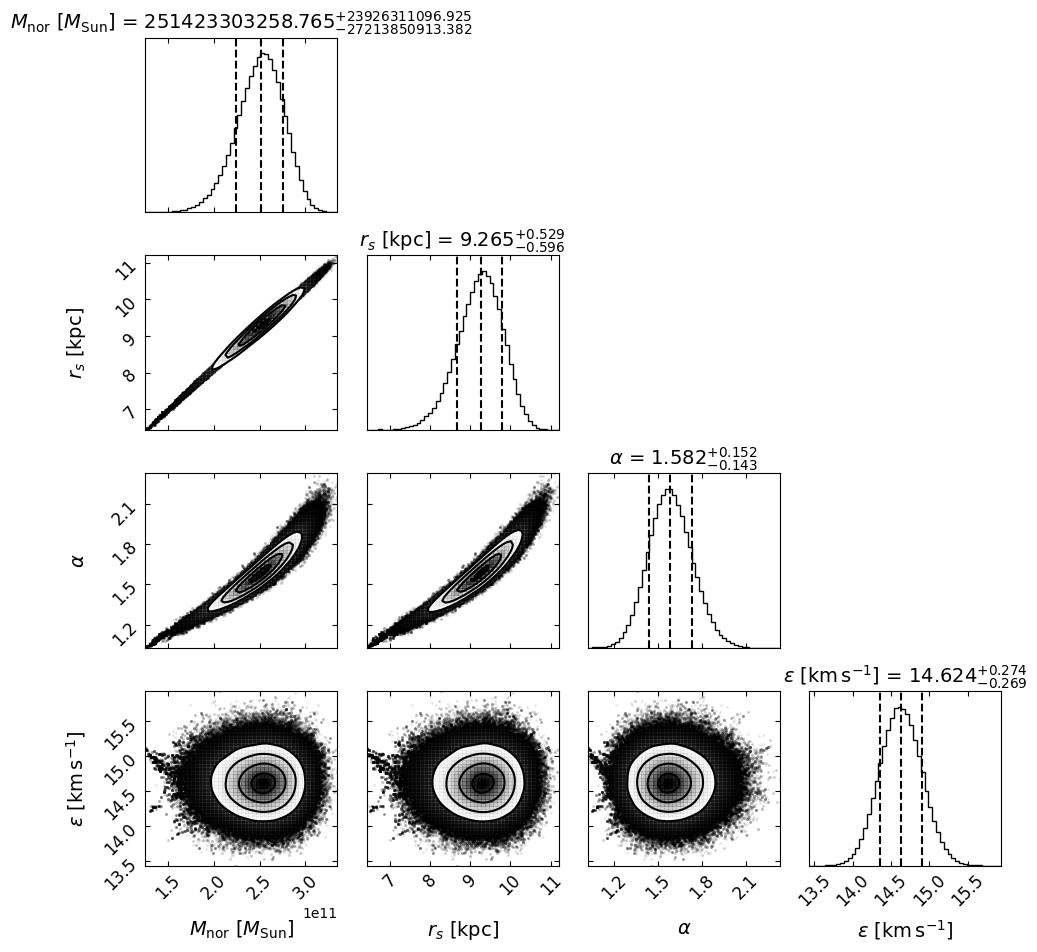

In [10]:
# stack the four parameter chains into one (n_samples, 4) array for corner
samples = np.column_stack([M_nor_s, r_s_s, alpha_s, eps_s])

labels = [
    r"$M_{\mathrm{nor}}\ [M_\mathrm{Sun}]$",
    r"$r_s\ [\mathrm{kpc}]$",
    r"$\alpha$",
    r"$\epsilon\ [\mathrm{km\,s^{-1}}]$",
]

# corner plot: 1D marginals and 2D parameter correlations
fig = corner.corner(
    samples,
    labels=labels,
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".3f",
    bins=50,
    smooth=1.0,
)

label_fs = 14
tick_fs = 12
title_fs = 14

for ax in fig.get_axes():
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=tick_fs,
    )
    ax.xaxis.label.set_size(label_fs)
    ax.yaxis.label.set_size(label_fs)
    ax.title.set_fontsize(title_fs)

plt.tight_layout()
plt.show()

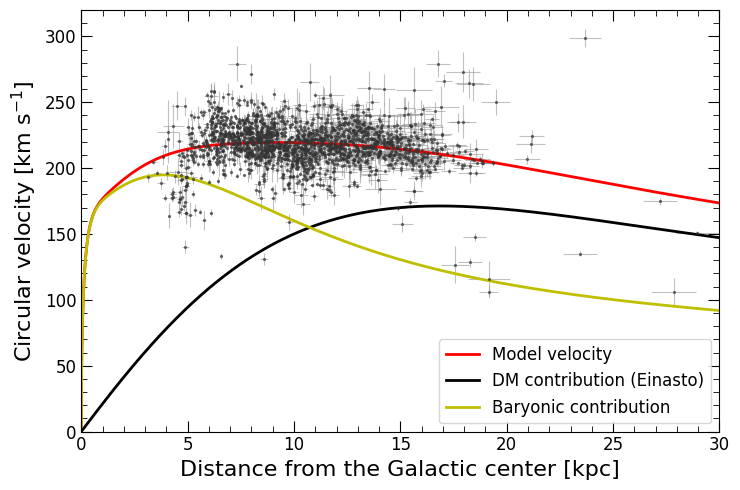

In [12]:
# rotation curve: Cepheid measurements against the median posterior model
fig, ax = plt.subplots(figsize=(7.5, 5.0))

# observed Cepheid rotation curve with error bars
ax.plot(
    R,
    V,
    linestyle="none",
    marker=".",
    markersize=3,
    markeredgewidth=0.8,
    alpha=0.6,
    color="0.2",
    zorder=3,
)
ax.errorbar(
    R,
    V,
    xerr=Rerr,
    yerr=Verr,
    fmt="none",
    ecolor="0.6",
    elinewidth=0.8,
    capsize=0,
    alpha=0.6,
    zorder=2,
)

# median posterior model and fixed baryonic contribution
thin_r = 100
Rline = r_arr[::thin_r]
Vline = model_velocity(M_nor_med, r_s_med, alpha_med, Rline)
Vdm_line = np.sqrt(G * enclosed_einasto_mass(M_nor_med, r_s_med, alpha_med, Rline) / Rline)
Wline = np.sqrt(v2_bar_arr[::thin_r])

# overlay total, DM, and baryonic component curves
ax.plot(Rline, Vline, "r-", lw=2, label="Model velocity")
ax.plot(Rline, Vdm_line, "k-", lw=2, label="DM contribution (Einasto)")
ax.plot(Rline, Wline, "y-", lw=2, label="Baryonic contribution")
ax.legend(fontsize=12)

ax.set_xlabel("Distance from the Galactic center [kpc]", fontsize=16)
ax.set_ylabel(r"Circular velocity [km s$^{-1}$]", fontsize=16)
ax.set_xlim(left=0, right=30)
ax.set_ylim(bottom=0, top=320)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(
    axis="both",
    which="major",
    labelsize=12,
    length=8,
    direction="in",
    top=True,
    bottom=True,
    left=True,
    right=True,
)
ax.tick_params(
    axis="both",
    which="minor",
    length=4,
    direction="in",
    top=True,
    bottom=True,
    left=True,
    right=True,
)
ax.minorticks_on()

plt.tight_layout()
plt.show()

The traces mix after the burn-in: walkers overlap and show no long stuck stretches, so the post-burn-in draws can be treated as posterior samples. The 1D marginals are unimodal and concentrated, away from the prior edges, which means the Cepheid data identify $M_{\mathrm{nor}}$, $r_s$, $\alpha$, and $\epsilon$ rather than leaving them unconstrained.

The model rotation curve declines at large galactocentric radii instead of staying flat, similarly to what Wang et al. (2023), Jiao et al. (2023), and Ou et al. (2024) found. The inferred total mass of the Galaxy (not calculated in this analysis) is also well below the classical $\sim 10^{12}\,M_\odot$ Milky Way mass scale.

### References

<small>Freeman, K. C. 1970, ApJ, 160, 811<br>
Rubin, V. C., Ford, W. K., Jr., & Thonnard, N. 1980, ApJ, 238, 471<br>
Sofue, Y. 2016, PASJ, 68, 2<br>
Sawala, T., Delhomelle, J., Deason, A. J., et al. 2025, Nat. Astron., 9, 1206<br>
Wang, H.-F., Chrobáková, Ž., López-Corredoira, M., & Sylos Labini, F. 2023, ApJ, 942, 12<br>
Jiao, Y., Hammer, F., Wang, H., et al. 2023, A&A, 678, A208<br>
Ou, X., Eilers, A.-C., Necib, L., & Frebel, A. 2024, MNRAS, 528, 693<br>
Leavitt, H. S. 1908, AnHar, 60, 87<br>
Storm, J., Gieren, W., Fouqué, P., Barnes, T. G., Pietrzyński, G., Nardetto, N., Weber, M., Granzer, T., & Strassmeier, K. G. 2011, A&A, 534, A95<br>
Skowron, D. M., Drimmel, R., Khanna, S., Spagna, A., Poggio, E., Ramos, P. 2025, ApJS, 278, 57<br>
Gaia Collaboration, Prusti, T., de Bruijne, J. H. J., et al. 2016, A&A, 595, A1<br>
de Salas, P. F., Malhan, K., Freese, K., Hattori, K., & Valluri, M. 2019, JCAP, 10, 037<br>
Foreman-Mackey, D., Hogg, D. W., Lang, D., & Goodman, J. 2013, PASP, 125, 306<br>
Hernquist, L. 1990, ApJ, 356, 359<br>
Einasto, J. 1965, Trudy Inst. Astrofiz. Alma-Ata, 5, 87<br>

# 3. Bayesian Inference in the Wild: Dunnhumby Transaction Elasticity


## 3.1 Price Elasticities in Grocery Retail

Grocery retailers routinely adjust shelf prices and run promotions. **Price elasticity** — how quantity demanded responds to price — is central to those decisions: it informs whether a price cut increases revenue, how aggressively to promote within a category, and how SKUs within the same aisle interact. This section focuses on **own-price elasticity**, which tells us how price-sensitive SKUs are individually, and uses **transaction-level data**, which preserves basket composition and provides granularity supporting within-day price variation.

Under **constant-elasticity** demand, quantity and price are linked by

$$
\log q = \alpha + \beta \log p,
$$

equivalently $q \propto p^{\beta}$. The slope $\beta = d\log q / d\log p$ is the **own-price elasticity**: the proportional change in quantity when price changes by 1%. Values below $-1$ mean elastic demand (quantity falls more than proportionally when price rises); above $-1$, inelastic. Because revenue $R = p\,q \propto p^{1+\beta}$, a 1% price cut changes revenue by roughly $(1+\beta)\%$.

The models are fitted in **`PyMC`**, a probabilistic-programming library for Bayesian models in Python. Instead of writing a single log-posterior function by hand, one declares **priors** and a **likelihood** directly in model code; **`PyMC`** builds the computational graph, applies parameter constraints, and evaluates the joint **posterior** automatically. **Hierarchical structure** — category-level hyperpriors with SKU-level deviations — fits naturally in this syntax, without manually flattening grouped parameters or re-deriving the log-density.

Posterior exploration uses **`PyMC`**'s default sampler, **NUTS** (No-U-Turn Sampler): the **`tune`** phase adapts step size and other sampler settings; the **`draws`** phase keeps post-warmup samples that approximate the posterior. NUTS belongs to the **Hamiltonian Monte Carlo** family, which treats sampling as simulating a physical system with **position** - $\theta$, **momentum** - $\mathbf{r}$, **potential energy** - $U(\theta)=-\log p(\theta\mid\text{data})$, **kinetic energy** - $K(\mathbf{r})=\tfrac{1}{2}\mathbf{r}^\top M^{-1}\mathbf{r}$, and **total energy** - $H(\theta,\mathbf{r})=U(\theta)+K(\mathbf{r})$. Rather than proposing small random steps, it uses the **gradient** of the log-posterior to propose long, coordinated moves that follow the local shape of high-probability regions — efficient when many parameters are correlated. Classical HMC requires choosing how long each trajectory runs; **NUTS** picks that length automatically by extending the trajectory until it starts to retrace its path (a "U-turn"), then stops.


## 3.2 Data

Transaction and product data come from **[Dunnhumby — The Complete Journey](https://www.kaggle.com/datasets/frtgnn/dunnhumby-the-complete-journey)** on Kaggle: an anonymised ~2-year household-level transaction panel from a grocery retailer. Each checkout line records basket ID, timestamp, product, quantity, and sales value; product metadata add a three-level merchandise hierarchy (department → commodity → sub-commodity). Two exported files are used — transaction lines and product attributes — and the analysis is restricted to seven chosen `SUB_COMMODITY_DESC` categories.


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle
import pymc as pm
import arviz as az

g++ not available, if using conda: `conda install gxx`


In [15]:
DATA_DIR = Path("data")

# analysis parameters
N_BASKETS_THRESHOLD = 10  # min distinct baskets per SKU for eligibility
N_PRICES_THRESHOLD = 10  # min distinct unit prices per SKU for eligibility
MIN_SALE_ROW_PCT = 0.05  # drop SKUs with sale_row_pct below this on the panel
N_NEAREST_PRICES = 1  # reference transaction(s) for zero-fill price imputation
NUTS_DRAWS = 1000  # posterior draws per chain
NUTS_TUNE = 500  # warmup iterations per chain

SELECTED_CATEGORIES = [
    "LAYER CAKE MIX",
    "MAINSTREAM WHITE BREAD",
    "FRUIT COCKTAIL FRUIT SALAD",
    "SFT DRNK 2 LITER BTL CARB INCL",
    "TOILET TISSUE",
    "KIDS CEREAL",
]

# load Dunnhumby CSVs
PRODUCT_PATH = DATA_DIR / "dunnhumby_product.csv"
TRANSACTION_PATH = DATA_DIR / "dunnhumby_transaction_data.csv"
product_df = pd.read_csv(PRODUCT_PATH)
tx_raw = pd.read_csv(TRANSACTION_PATH)

# inner join on PRODUCT_ID: keep only checkout lines with product metadata
joined = tx_raw.merge(
    product_df[["PRODUCT_ID", "SUB_COMMODITY_DESC"]],
    on="PRODUCT_ID",
    how="inner",
)

# retain positive-quantity, positive-value sales; derive unit price
joined = joined[(joined["QUANTITY"] > 0) & (joined["SALES_VALUE"] > 0)].copy()
joined["sku"] = joined["PRODUCT_ID"]
joined["sku_category"] = joined["SUB_COMMODITY_DESC"].astype(str)
joined["quantity"] = joined["QUANTITY"].astype(float)
joined["price"] = joined["SALES_VALUE"] / joined["quantity"]
# composite time key for temporal price imputation (day + transaction time)
# composite key orders baskets within a day for nearest-time price imputation
joined["time_key"] = joined["DAY"] * 1_000_000 + joined["TRANS_TIME"]

# slim column set passed to panel builder and downstream filters
dunnhumby_tx = joined[
    ["BASKET_ID", "sku", "sku_category", "quantity", "price", "time_key", "RETAIL_DISC"]
].copy()

# SKUs need enough baskets and price variation to identify elasticity
selected_tx = dunnhumby_tx[dunnhumby_tx["sku_category"].isin(SELECTED_CATEGORIES)]
n_baskets = selected_tx.groupby("sku")["BASKET_ID"].transform("nunique")
n_prices = selected_tx.groupby("sku")["price"].transform("nunique")
# both thresholds must pass simultaneously
SELECTED_PRODUCTS = sorted(
    selected_tx.loc[
        (n_baskets > N_BASKETS_THRESHOLD) & (n_prices > N_PRICES_THRESHOLD), "sku"
    ]
    .unique()
    .tolist()
)

print(
    f"Dunnhumby: {len(dunnhumby_tx):,} rows | {dunnhumby_tx['sku'].nunique():,} products | "
    f"{dunnhumby_tx['BASKET_ID'].nunique():,} baskets"
)
print(
    f"Modeling subset: {len(SELECTED_PRODUCTS)} eligible SKUs in "
    f"{len(SELECTED_CATEGORIES)} categories"
)

Dunnhumby: 2,576,815 rows | 91,905 products | 275,539 baskets
Modeling subset: 96 eligible SKUs in 6 categories


## 3.3 Preprocessing

SKUs passing basket and price thresholds are screened on in-category basket coverage. Those with fewer than 5% sale rows on the counterfactual panel are dropped. The remaining set is expanded into a **zero-filled basket×SKU panel**: for each category, any basket containing at least one selected SKU is filled out to all selected SKUs in that category (zero quantity when absent, nearest-time price imputation). The cells below report how many SKUs survive the coverage filter, a per-category diagnostics table, and a stacked bar chart of sale rows versus zero-fill rows in the final panel.


In [16]:
def impute_price_k_nearest(ref_times, ref_prices, target_time, k=1):
    """Impute unit price for a zero-fill row from the k nearest sales by time_key."""
    if len(ref_times) == 0:
        return None
    dists = np.abs(ref_times - target_time)
    order = np.argsort(dists)
    take = order[: min(k, len(order))]
    return float(np.mean(ref_prices[take]))

def build_dunnhumby_basket_panel(tx, selected_products, *, n_nearest=1):
    """Build a category-scoped basket×SKU panel for elasticity modelling."""
    # restrict to modeling-eligible SKUs only
    products = tx[tx["sku"].isin(selected_products)].copy()
    ref = products[(products["quantity"] > 0) & (products["price"] > 0)]
    # per-SKU sale times and unit prices — reference for zero-fill imputation
    ref_by_sku = {
        sku: (grp["time_key"].to_numpy(dtype=float), grp["price"].to_numpy(dtype=float))
        for sku, grp in ref.groupby("sku")
    }
    prod_meta = (
        products[["sku", "sku_category"]]
        .drop_duplicates()
        .set_index("sku")["sku_category"]
        .to_dict()
    )
    # group selected SKUs by category — basket universe is scoped per category
    selected_by_cat = {}
    for sku in selected_products:
        cat = prod_meta.get(sku)
        if cat is not None:
            selected_by_cat.setdefault(cat, []).append(sku)
    observed = products.set_index(["BASKET_ID", "sku"])
    rows = []
    # basket universe scoped per category (categories never share baskets)
    for category, cat_skus in selected_by_cat.items():
        cat_tx = products[products["sku"].isin(cat_skus)]
        # baskets that contain any selected SKU in this category
        basket_times = cat_tx.groupby("BASKET_ID")["time_key"].first().to_dict()
        for basket_id, target_time in basket_times.items():
            target_time = float(target_time)
            # expand each basket to all category SKUs (full basket×SKU grid)
            for sku in cat_skus:
                if (basket_id, sku) in observed.index:
                    # observed line: actual quantity and checkout price
                    row = observed.loc[(basket_id, sku)]
                    if isinstance(row, pd.DataFrame):
                        row = row.iloc[0]
                    rows.append(
                        {
                            "BASKET_ID": basket_id,
                            "sku": sku,
                            "sku_category": category,
                            "time_key": target_time,
                            "quantity": float(row["quantity"]),
                            "price": float(row["price"]),
                            "price_imputed": False,
                        }
                    )
                else:
                    # zero-fill: q=0, price from nearest sale of this SKU
                    ref_times, ref_prices = ref_by_sku.get(sku, (np.array([]), np.array([])))
                    price = impute_price_k_nearest(ref_times, ref_prices, target_time, k=n_nearest)
                    # drop this (basket, SKU) pair if no price history
                    if price is None or price <= 0:
                        continue
                    rows.append(
                        {
                            "BASKET_ID": basket_id,
                            "sku": sku,
                            "sku_category": category,
                            "time_key": target_time,
                            "quantity": 0.0,
                            "price": price,
                            "price_imputed": True,
                        }
                    )
    panel = pd.DataFrame(rows)
    # log-log model inputs
    panel["log_price"] = np.log(panel["price"])
    panel["log_quantity"] = np.log1p(panel["quantity"])
    return panel

def finalize_dunnhumby_panel(panel):
    """Sort panel and return PyMC-ready integer indices and log arrays."""
    panel = panel.sort_values(["sku_category", "sku", "BASKET_ID"]).reset_index(drop=True)
    cat_order = sorted(panel["sku_category"].unique())
    sku_order = (
        panel.sort_values(["sku_category", "sku"]).drop_duplicates("sku")["sku"].tolist()
    )
    # categoricals give stable PyMC coordinate labels and integer codes
    panel["sku_category"] = pd.Categorical(panel["sku_category"], categories=cat_order, ordered=True)
    panel["sku"] = pd.Categorical(panel["sku"], categories=sku_order, ordered=True)
    sku_labels = panel["sku"].cat.categories.to_numpy()
    cat_labels = panel["sku_category"].cat.categories.to_numpy()
    # row-level indices: map each observation to its SKU / category group
    sku_idx = panel["sku"].cat.codes.to_numpy()
    cat_idx = panel["sku_category"].cat.codes.to_numpy()
    sku_cat_map = (
        panel[["sku", "sku_category"]]
        .drop_duplicates()
        .assign(
            sku_code=lambda d: d["sku"].cat.codes,
            cat_code=lambda d: d["sku_category"].cat.codes,
        )
        .sort_values("sku_code")
    )
    # one category code per SKU — used by the hierarchical model
    sku_to_cat = sku_cat_map["cat_code"].to_numpy()
    return {
        "panel": panel,
        "sku_labels": sku_labels,
        "cat_labels": cat_labels,
        "sku_idx": sku_idx,
        "cat_idx": cat_idx,
        "sku_to_cat": sku_to_cat,
        # flat arrays consumed directly by PyMC likelihood
        "log_price": panel["log_price"].to_numpy(),
        "log_quantity": panel["log_quantity"].to_numpy(),
    }

def category_basket_stats(tx, skus, category):
    """Basket-coverage diagnostics for a SKU list within one category universe."""
    cat_tx = tx[(tx["sku_category"] == category) & (tx["sku"].isin(skus))]
    # category-scoped basket universe (not global)
    universe = set(cat_tx["BASKET_ID"].unique())
    n_universe = len(universe)
    if n_universe == 0:
        return None
    missing_pcts = []
    for sku in skus:
        n_with_sale = cat_tx.loc[cat_tx["sku"] == sku, "BASKET_ID"].nunique()
        # share of category-universe baskets where this SKU was not purchased
        missing_pcts.append(1.0 - n_with_sale / n_universe)
    return {
        "n_skus": len(skus),
        "n_baskets_universe": n_universe,
        "mean_missing_pct": float(np.mean(missing_pcts)),
        "pct_skus_ge_5pct": float(np.mean([1.0 - m >= MIN_SALE_ROW_PCT for m in missing_pcts])),
    }

In [17]:
# threshold-eligible SKUs grouped by category (pre coverage filter)
eligible_by_cat = {}
for category in SELECTED_CATEGORIES:
    cat_skus = [
        s
        for s in SELECTED_PRODUCTS
        if dunnhumby_tx.loc[dunnhumby_tx["sku"] == s, "sku_category"].iloc[0] == category
    ]
    eligible_by_cat[category] = cat_skus

# basket-coverage diagnostics before zero-fill (eligible SKUs per category)
pre_stats_rows = []
for category, cat_skus in eligible_by_cat.items():
    stats = category_basket_stats(dunnhumby_tx, cat_skus, category)
    if stats:
        pre_stats_rows.append({"category": category, **stats})

# temporary full panel to measure each SKU's sale-row share on the counterfactual grid
ref_panel = build_dunnhumby_basket_panel(dunnhumby_tx, SELECTED_PRODUCTS, n_nearest=N_NEAREST_PRICES)
pre_filter = (
    ref_panel.groupby(["sku_category", "sku"])
    .agg(n_panel_rows=("price", "size"), n_sale_rows=("quantity", lambda s: (s > 0).sum()))
    .assign(sale_row_pct=lambda d: d["n_sale_rows"] / d["n_panel_rows"])
    .reset_index()
)
# drop SKUs mostly absent from their category basket universe
MODELING_PRODUCTS = (
    pre_filter.loc[pre_filter["sale_row_pct"] >= MIN_SALE_ROW_PCT, "sku"].astype(int).tolist()
)
print(
    f"Coverage filter: {len(MODELING_PRODUCTS)} modeling SKUs "
    f"({len(SELECTED_PRODUCTS) - len(MODELING_PRODUCTS)} dropped)"
)

# recompute universe stats on surviving SKUs
filtered_by_cat = {}
for category in SELECTED_CATEGORIES:
    filtered_by_cat[category] = [
        s for s in MODELING_PRODUCTS if s in eligible_by_cat.get(category, [])
    ]

post_filter_rows = []
for category, cat_skus in filtered_by_cat.items():
    stats = category_basket_stats(dunnhumby_tx, cat_skus, category)
    if stats:
        post_filter_rows.append(
            {
                "category": category,
                "n_skus_eligible": stats["n_skus"],
                "n_baskets_eligible": stats["n_baskets_universe"],
                "mean_missing_pct_eligible": stats["mean_missing_pct"],
            }
        )

# rebuild panel on filtered SKU set (smaller, higher signal)
dunnhumby_panel = build_dunnhumby_basket_panel(
    dunnhumby_tx, MODELING_PRODUCTS, n_nearest=N_NEAREST_PRICES
)
# unpack integer indices and log arrays consumed by PyMC
fin = finalize_dunnhumby_panel(dunnhumby_panel)
dunnhumby_panel = fin["panel"]
sku_labels = fin["sku_labels"]
cat_labels = fin["cat_labels"]
sku_idx = fin["sku_idx"]
cat_idx = fin["cat_idx"]
sku_to_cat = fin["sku_to_cat"]
log_price = fin["log_price"]
log_quantity = fin["log_quantity"]

Coverage filter: 39 modeling SKUs (57 dropped)


,n_skus,n_baskets_universe,mean_missing_pct,pct_skus_ge_5pct,n_skus_eligible,n_baskets_eligible,mean_missing_pct_eligible,n_panel_rows,n_sale_rows
category,,,,,,,,,
LAYER CAKE MIX,5,993,0.7889,1.0000,5,993,0.7889,4965,1048
MAINSTREAM WHITE BREAD,14,23627,0.9274,0.3571,5,19199,0.7980,95995,19388
FRUIT COCKTAIL FRUIT SALAD,5,524,0.7905,1.0000,5,524,0.7905,2620,549
SFT DRNK 2 LITER BTL CARB INCL,42,19563,0.9657,0.2143,9,13192,0.8629,118728,16274
TOILET TISSUE,18,7976,0.9442,0.3333,6,5916,0.8332,35496,5922
KIDS CEREAL,12,3115,0.9086,0.7500,9,2721,0.8785,24489,2976


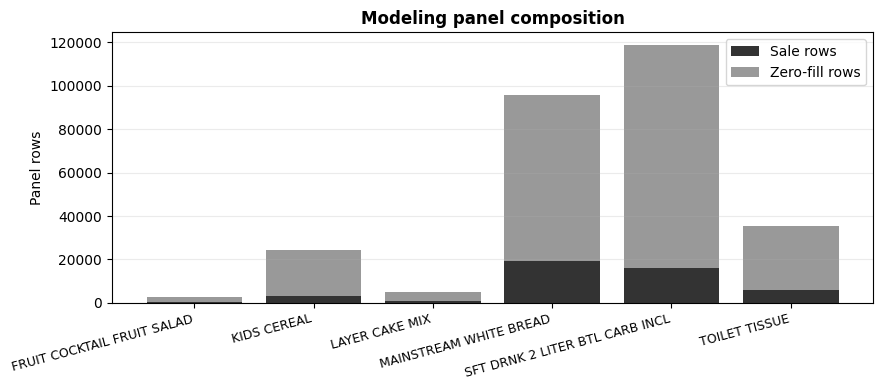

Panel: 282,293 rows | 37,183 baskets | 39 SKUs | response=log(1+q)


In [18]:
# final-panel row counts: actual sales vs imputed-price zero-fills
panel_stats = (
    dunnhumby_panel.groupby("sku_category")
    .agg(
        n_panel_rows=("price", "size"),
        n_sale_rows=("quantity", lambda s: (s > 0).sum()),
    )
    .rename_axis("category")
    .reindex(cat_labels)
)

# merge pre-filter, post-filter, and panel stats into one table per category
pre_df = pd.DataFrame(pre_stats_rows).set_index("category")
post_df = pd.DataFrame(post_filter_rows).set_index("category")
category_stats = pre_df.join(post_df, how="outer").join(panel_stats, how="outer")
category_stats = category_stats.reindex(SELECTED_CATEGORIES).round(4)
display(category_stats)

# visualise per-category sale and zero-fill row counts
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(cat_labels))
sale_counts = panel_stats["n_sale_rows"].to_numpy()
zero_counts = (panel_stats["n_panel_rows"] - panel_stats["n_sale_rows"]).to_numpy()
ax.bar(x, sale_counts, label="Sale rows", color="0.2")
ax.bar(x, zero_counts, bottom=sale_counts, label="Zero-fill rows", color="0.6")
ax.set_xticks(x)
ax.set_xticklabels(cat_labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Panel rows")
ax.set_title("Modeling panel composition", fontweight="bold")
ax.legend(loc="upper right")
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

# sanity check on PyMC input dimensions
print(
    f"Panel: {len(dunnhumby_panel):,} rows | {dunnhumby_panel['BASKET_ID'].nunique():,} baskets | "
    f"{len(sku_labels)} SKUs | response=log(1+q)"
)

## 3.4 Modelling

Each basket×SKU observation follows

$$
\log(1+q_i) \sim \mathcal{N}\!\left(\alpha_{s[i]} + \beta_{s[i]}\,\log p_i,\ \sigma_{s[i]}\right),
$$

meaning that the **logarithm of (1 + quantity)** for observation i is modeled as a linear function of **logarithm of price** with $\alpha_s$ being a SKU-specific intercept (baseline log-demand), $\beta_s$ being the elasticity slope on log price, and $\sigma_s$ being the residual spread around that mean. $\log(1+q)$ is used rather than $\log q$ because the panel includes zero-quantity rows.

Two models are built. The **simple** model estimates independent $(\alpha_s, \beta_s, \sigma_s)$ per SKU. The **hierarchical** model partially pools $\beta_s$ across `SUB_COMMODITY_DESC` categories via a non-centered parameterization - SKUs in the same category are drawn toward a common category mean, so data-sparse products borrow strength from better-observed neighbours rather than being estimated in isolation. Concretely, each category elasticity is built as $\beta_c = \beta_{\text{global}} + z_c\sigma_{\beta,c}$, and each SKU elasticity as $\beta_s = \beta_{c[s]} + z_s\sigma_{\beta,s}$. Weak priors are used: $\mathcal{N}(0,1)$ on intercepts and slopes, $\text{HalfNormal}(1)$ on scales (standard deviations).

This is a non-centered parameterization: rather than sampling $\beta_c$ and $\beta_s$ directly from $\mathcal{N}(\beta_{\text{global}}, \sigma_{\beta,c})$ and $\mathcal{N}(\beta_{c[s]}, \sigma_{\beta,s})$ (the centered form, which can create a narrow funnel when scales are small and frustrate NUTS), standard normals $z_c, z_s$ are sampled, and deterministically scaled and shifted. The statistical model is unchanged, but the geometry of the posterior is easier to explore.

In [19]:
# plotting helpers

def add_category_forest_guides(ax, sku_to_cat_ord, cat_labels_arr):
    """Shade y-axis blocks by category; labels left of axis."""
    # initialise category block start position, category 
    # and category block alternating between even and odd
    block_start, current_cat, cat_block = 0, int(sku_to_cat_ord[0]), 0
    for i in range(1, len(sku_to_cat_ord) + 1): # go through the categories
        # when new category starts
        if (i == len(sku_to_cat_ord)) or (int(sku_to_cat_ord[i]) != current_cat):
            # change shading colour
            shade = "0.92" if cat_block % 2 == 0 else "1.00" 
            # shade the category section of the plot
            ax.axhspan(block_start - 0.5, i - 0.5, color=shade, alpha=0.5, zorder=0)
            # add category name to y-axis
            ax.text(-0.06, (block_start + i - 1) / 2, cat_labels_arr[current_cat],
                    transform=ax.get_yaxis_transform(), ha="right", va="center",
                    fontweight="bold", clip_on=False)
            if i != len(sku_to_cat_ord):
                # add line separating sections
                ax.axhline(i - 0.5, color="0.35", linewidth=1.2, zorder=1)
                # update parameters
                block_start, current_cat, cat_block = i, int(sku_to_cat_ord[i]), cat_block + 1

def flatten_posterior(idata, var_name):
    """Collapse (chain, draw, group) posterior samples to (draw, group)."""
    arr = idata.posterior[var_name].values
    return arr.reshape(-1, arr.shape[-1])

def plot_elasticity_forest(ax, samples, title, color="C0", offset=0.0):
    """Plot per-group median with a 94% equal-tailed interval (3rd–97th pct)."""
    lo, med, hi = np.percentile(samples, [3, 50, 97], axis=0)
    y = np.arange(samples.shape[1]) + offset
    ax.errorbar(
        med, y, xerr=np.vstack([med - lo, hi - med]), fmt="o", 
        color=color, capsize=3, markersize=4, elinewidth=1.2, label=title,
    )
    return y

def format_elasticity_forest(yticks, ytickslabels, title, adjust=True):
    """Format axes, title, legend, grid and add static components to elasticity forest plot"""
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytickslabels, fontsize=7)
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
    ax.axvline(-1.0, color="red", linestyle="-.", linewidth=1, label="elastic / inelastic")
    ax.set_xlabel(r"elasticity $\beta$")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(loc="best")
    ax.grid(alpha=0.25, axis="x")
    plt.tight_layout()
    if adjust:
        fig.subplots_adjust(left=0.38)
    plt.show()

# plate-diagram helpers - hand-drawn stand-in for pm.model_to_graphviz, which needs a Graphviz binary
PLATE_NODE_RADIUS = 0.5

def draw_plate_node(ax, xy, label, kind="latent", fontsize=9):
    """Draw one plate node: sampled (open circle), observed (shaded) or deterministic (dashed box)."""
    x, y = xy
    if kind == "deterministic":
        # dashed box - computed from its parents rather than sampled
        node = FancyBboxPatch(
            (x - 0.7 * PLATE_NODE_RADIUS, y - 0.45 * PLATE_NODE_RADIUS),
            1.4 * PLATE_NODE_RADIUS, 0.9 * PLATE_NODE_RADIUS,
            boxstyle="round,pad=0.1", facecolor="white", edgecolor="0.25",
            linestyle="--", linewidth=1.2, zorder=2,
        )
    else:
        # shaded circle marks data the model conditions on; open circle marks an unknown
        node = Circle(
            xy, PLATE_NODE_RADIUS, facecolor="0.85" if kind == "observed" else "white",
            edgecolor="0.25", linewidth=1.4, zorder=2,
        )
    ax.add_patch(node)
    # long labels need a smaller size to stay inside the node
    ax.text(x, y, label, ha="center", va="center", fontsize=fontsize, zorder=3)
    # returned so arrows can be attached without repeating the coordinates
    return xy

def draw_plate_box(ax, xy, width, height, label):
    """Draw a plate rectangle with its index label in the lower-right corner."""
    ax.add_patch(
        Rectangle(xy, width, height, facecolor="none", edgecolor="0.45", linewidth=1.2, zorder=1)
    )
    # plate label states how many times the enclosed variables are repeated
    ax.text(xy[0] + width - 0.15, xy[1] + 0.12, label, ha="right", va="bottom",
            fontsize=9, style="italic", color="0.3", zorder=1)

def connect_plate_nodes(ax, start, end):
    """Arrow from one node centre to another, trimmed so the head stops at the node edge."""
    (x0, y0), (x1, y1) = start, end
    # unit vector along the connection - used to pull both ends off the node centres
    dist = np.hypot(x1 - x0, y1 - y0)
    ux, uy = (x1 - x0) / dist, (y1 - y0) / dist
    pad = PLATE_NODE_RADIUS + 0.05
    ax.annotate(
        "", xy=(x1 - ux * pad, y1 - uy * pad), xytext=(x0 + ux * pad, y0 + uy * pad),
        arrowprops=dict(arrowstyle="-|>", color="0.35", linewidth=1.2, shrinkA=0, shrinkB=0),
        zorder=1,
    )

def format_plate_axes(ax, xlim, ylim, title):
    """Turn the axes into a blank, equal-aspect canvas and add the caption legend."""
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    # equal aspect keeps the nodes circular rather than elliptical
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold")
    # doubles as a legend for the three node styles
    ax.text(xlim[0], ylim[0], "open = sampled,  dashed = deterministic,  shaded = observed",
            ha="left", va="bottom", fontsize=8, color="0.35")

In [20]:
# unpooled (simple) per-SKU elasticity model

# define the model
with pm.Model(coords={"sku": sku_labels}) as dh_simple_model:
    # prior - alpha_s: SKU baseline log-demand
    intercept_sku = pm.Normal("intercept_sku", mu=0.0, sigma=1.0, dims="sku")
    # prior - beta_sku: elasticity; 1% price -> ~beta% quantity
    beta_sku = pm.Normal("beta_sku", mu=0.0, sigma=1.0, dims="sku")
    # prior - residual SD; HalfNormal because sigma > 0
    sigma_sku = pm.HalfNormal("sigma_sku", sigma=1.0, dims="sku")
    # linear predictor per panel row
    expected_log_quantity = intercept_sku[sku_idx] + beta_sku[sku_idx] * log_price
    # likelihood - the response log_quantity[i] is normally distributed around expected_log_quantity[i]
    # with standard deviation sigma_sku[sku_idx[i]] - each observation has a predicted
    # quantity value but the spread is per SKU
    pm.Normal("obs", mu=expected_log_quantity, sigma=sigma_sku[sku_idx], observed=log_quantity)

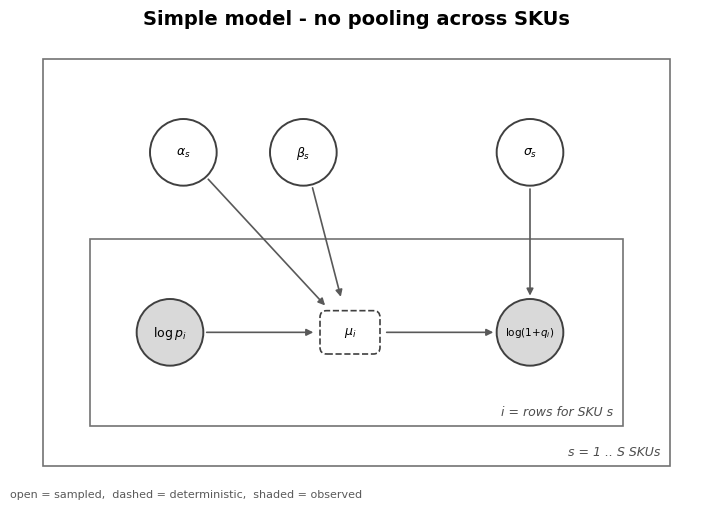

In [21]:
# visualise the simple model with a plate diagram
fig, ax = plt.subplots(figsize=(8.0, 5.2))

# outer plate: parameters repeated once per SKU
draw_plate_box(ax, (0.5, 0.5), 9.4, 6.1, "s = 1 .. S SKUs")
# inner plate: the basket x SKU rows belonging to that SKU
draw_plate_box(ax, (1.2, 1.1), 8.0, 2.8, "i = rows for SKU s")

# per-SKU parameters: baseline demand, elasticity and residual spread
alpha_s = draw_plate_node(ax, (2.6, 5.2), r"$\alpha_s$")
beta_s = draw_plate_node(ax, (4.4, 5.2), r"$\beta_s$")
sigma_s = draw_plate_node(ax, (7.8, 5.2), r"$\sigma_s$")

# row-level quantities: observed price, deterministic mean, observed response
log_p_i = draw_plate_node(ax, (2.4, 2.5), r"$\log p_i$", kind="observed")
mu_i = draw_plate_node(ax, (5.1, 2.5), r"$\mu_i$", kind="deterministic")
obs_i = draw_plate_node(ax, (7.8, 2.5), r"$\log(1{+}q_i)$", kind="observed", fontsize=7.5)

# linear predictor E[log(1+q_i)] = intercept_sku + beta_sku * log p_i
for parent in (alpha_s, beta_s, log_p_i):
    connect_plate_nodes(ax, parent, mu_i)
# likelihood - mean from the linear predictor, spread from the SKU's own sigma
connect_plate_nodes(ax, mu_i, obs_i)
connect_plate_nodes(ax, sigma_s, obs_i)

format_plate_axes(ax, (0.0, 10.4), (0.0, 7.0), "Simple model - no pooling across SKUs")
plt.tight_layout()
plt.show()

In [22]:
# NetCDF file holding the full InferenceData
simple_idata_path = Path("chains/price_elasticity_simple.nc")
simple_idata_path.parent.mkdir(exist_ok=True)

# NUTS only runs when there is no saved posterior on disk
if not simple_idata_path.exists():
    with dh_simple_model:
        dh_simple_idata = pm.sample(  # an InferenceData object
            draws=NUTS_DRAWS, tune=NUTS_TUNE, target_accept=0.9, chains=4, random_seed=42
        )
    # write all posterior draws so later runs can reuse this fit
    dh_simple_idata.to_netcdf(simple_idata_path)
    print(f"Saved posterior to {simple_idata_path}")
else:
    # reload instead of resampling
    dh_simple_idata = az.from_netcdf(simple_idata_path)
    print(f"Posterior already exists at {simple_idata_path}; skipping sampling.")

NUTS[nutpie]: [intercept_sku, beta_sku, sigma_sku]


Output()

Saved posterior to chains\price_elasticity_simple.nc


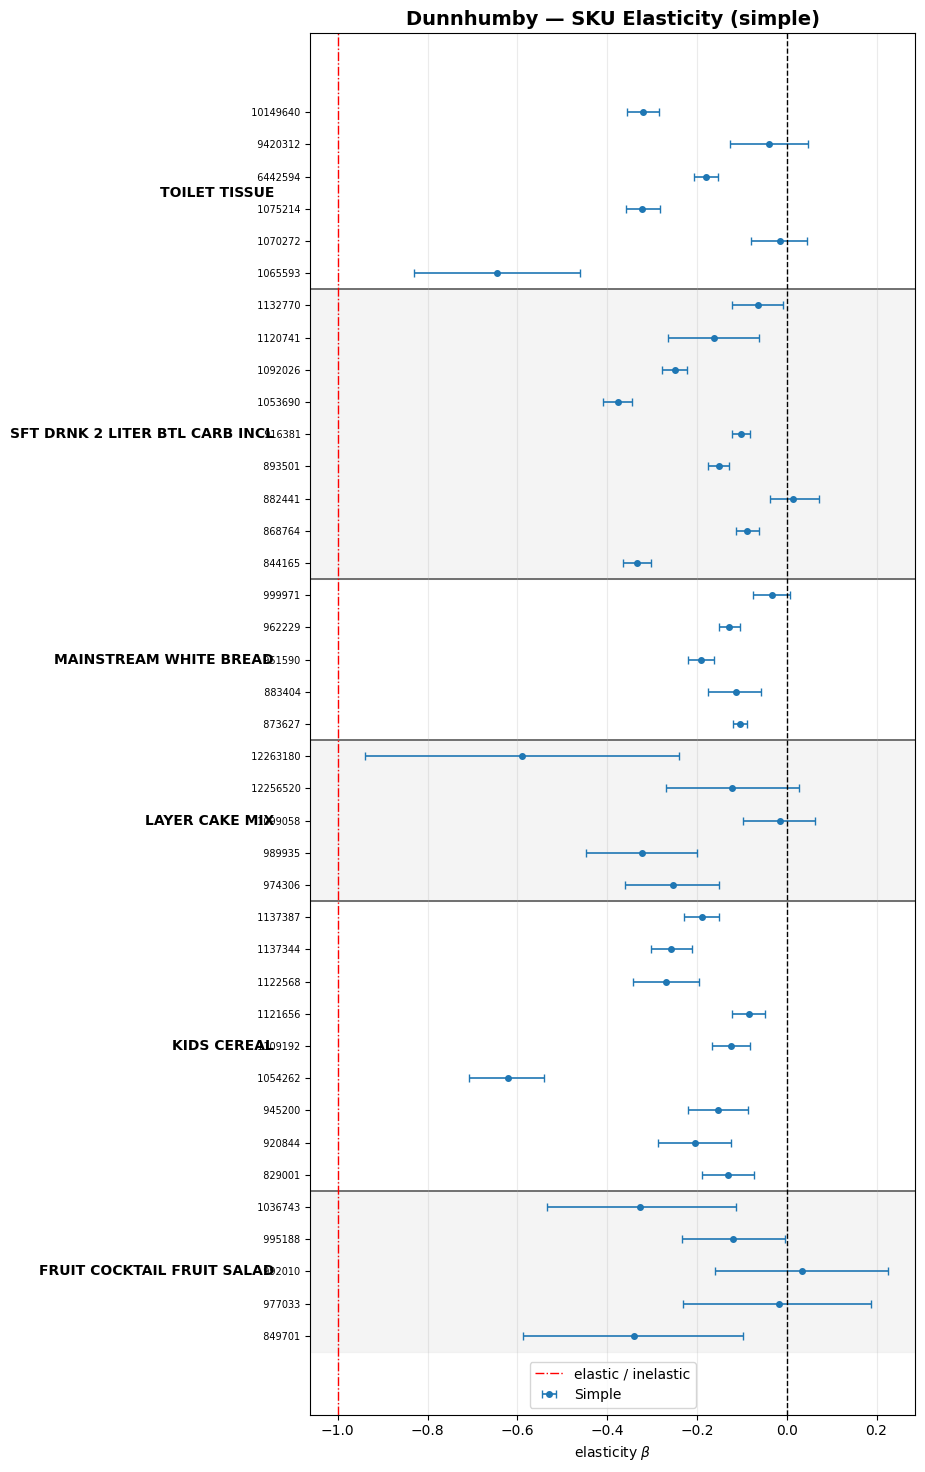

In [23]:
# idata.posterior["variable"] has shape (n_chains, n_draws, n_skus)
# after flattening, shape (n_draws, n_skus) for forest plots
beta_dh_simple = flatten_posterior(dh_simple_idata, "beta_sku")  

# sort SKUs by category for grouped forest; lexsort: primary=category, secondary=SKU name
order = np.lexsort((sku_labels, sku_to_cat))
sku_ord = sku_labels[order]
sku_to_cat_ord = sku_to_cat[order]
cat_labels_arr = np.asarray(cat_labels)

fig, ax = plt.subplots(figsize=(10, max(4.5, 0.38 * len(sku_labels))))
# shade + label category blocks before error bars
add_category_forest_guides(ax, sku_to_cat_ord, cat_labels_arr)  
samples_ord = beta_dh_simple[:, order]
y = plot_elasticity_forest(ax, samples_ord, "Simple")
format_elasticity_forest(y, [f"  {s}" for s in sku_ord], "Dunnhumby — SKU Elasticity (simple)")

In [24]:
# hierarchical model with partial pooling across SUB_COMMODITY_DESC

# define the model
with pm.Model(coords={"sku": sku_labels, "sku_category": cat_labels}) as dh_hier_model:
    # global mean elasticity cross all categories
    beta_global = pm.Normal("beta_global", mu=0.0, sigma=1.0)
    # spread of category elasticities around the global mean
    sigma_beta_cat_global = pm.HalfNormal("sigma_beta_cat_global", sigma=1.0)
    # spread of sku elasticities around the mean of their category
    # a single distribution which best explains those deviations across all SKUs, pooling over categories
    # uses all SKUs for estimation instead of n_cat separate distributions, each estimated by a small number of SKUs
    sigma_beta_sku_global = pm.HalfNormal("sigma_beta_sku_global", sigma=1.0)
    # global scale for observation-noise hierarchy
    sigma_global = pm.HalfNormal("sigma_global", sigma=1.0)
    # category-level standard normal for non-centered parameterization
    z_cat = pm.Normal("z_cat", mu=0.0, sigma=1.0, dims="sku_category")
    beta_cat = pm.Deterministic("beta_cat", beta_global + z_cat * sigma_beta_cat_global, dims="sku_category")
    # per-category residual standard deviation
    sigma_cat = pm.HalfNormal("sigma_cat", sigma=sigma_global, dims="sku_category")
    # sku-level standard normal for non-centered parameterization
    z_sku = pm.Normal("z_sku", mu=0.0, sigma=1.0, dims="sku")
    # SKU elasticity = category effect + SKU-level deviation (partial pooling)
    beta_sku = pm.Deterministic("beta_sku", beta_cat[sku_to_cat] + z_sku * sigma_beta_sku_global, dims="sku")
    # unpooled per-sku intercept - each SKU's average demand level is estimated on its own
    intercept_sku = pm.Normal("intercept_sku", mu=0.0, sigma=1.0, dims="sku")
    # per-sku residual standard deviation
    sigma_sku = pm.HalfNormal("sigma_sku", sigma=sigma_cat[sku_to_cat], dims="sku")
    # same likelihood as simple model
    expected_log_quantity = intercept_sku[sku_idx] + beta_sku[sku_idx] * log_price
    pm.Normal("obs", mu=expected_log_quantity, sigma=sigma_sku[sku_idx], observed=log_quantity)

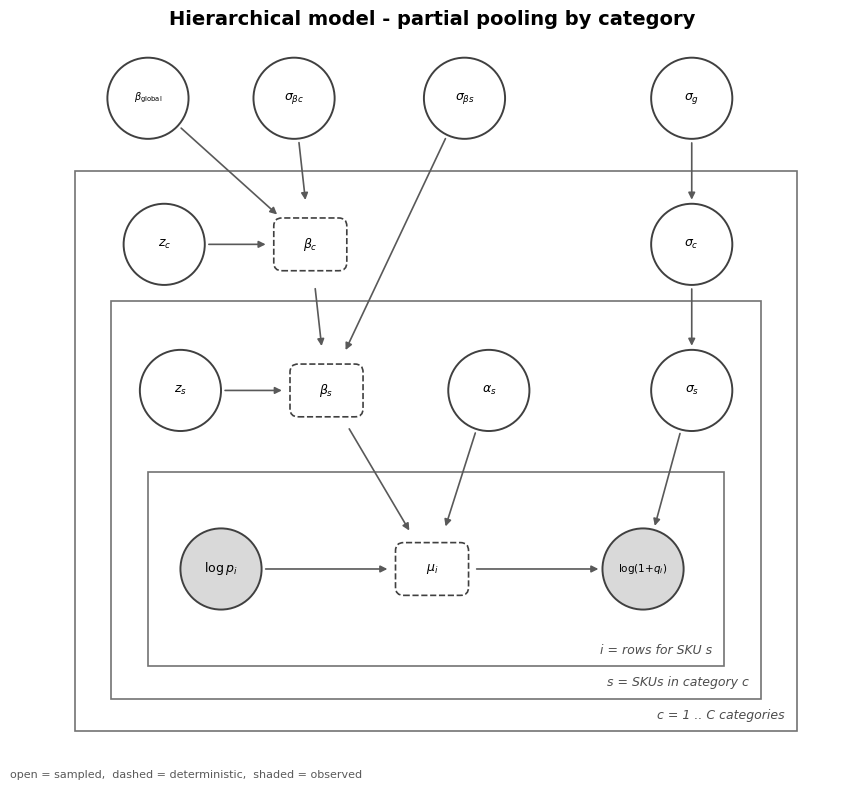

In [25]:
# visualise the hierarchical model with a plate diagram 
fig, ax = plt.subplots(figsize=(9.5, 8.0))

# nested plates: categories contain SKUs, SKUs contain their basket rows
draw_plate_box(ax, (0.8, 0.6), 8.9, 6.9, "c = 1 .. C categories")
draw_plate_box(ax, (1.25, 1.0), 8.0, 4.9, "s = SKUs in category c")
draw_plate_box(ax, (1.7, 1.4), 7.1, 2.4, "i = rows for SKU s")

# hyperpriors shared by every category and SKU
beta_global = draw_plate_node(ax, (1.7, 8.4), r"$\beta_{\mathrm{global}}$", fontsize=7)
sigma_beta_c = draw_plate_node(ax, (3.5, 8.4), r"$\sigma_{\beta c}$")
sigma_beta_s = draw_plate_node(ax, (5.6, 8.4), r"$\sigma_{\beta s}$")
sigma_glob = draw_plate_node(ax, (8.4, 8.4), r"$\sigma_{g}$")

# category level - beta_cat is built from a standard normal
z_c = draw_plate_node(ax, (1.9, 6.6), r"$z_c$")
beta_c = draw_plate_node(ax, (3.7, 6.6), r"$\beta_c$", kind="deterministic")
sigma_c = draw_plate_node(ax, (8.4, 6.6), r"$\sigma_c$")

# SKU level - beta_sku is also built from a standard normal
z_s = draw_plate_node(ax, (2.1, 4.8), r"$z_s$")
beta_s = draw_plate_node(ax, (3.9, 4.8), r"$\beta_s$", kind="deterministic")
alpha_s = draw_plate_node(ax, (5.9, 4.8), r"$\alpha_s$")
sigma_s = draw_plate_node(ax, (8.4, 4.8), r"$\sigma_s$")

# row level - identical to the simple model once beta_sku is known
log_p_i = draw_plate_node(ax, (2.6, 2.6), r"$\log p_i$", kind="observed")
mu_i = draw_plate_node(ax, (5.2, 2.6), r"$\mu_i$", kind="deterministic")
obs_i = draw_plate_node(ax, (7.8, 2.6), r"$\log(1{+}q_i)$", kind="observed", fontsize=7.5)

# beta_cat = beta_global + z_cat * sigma_beta_cat_global
for parent in (beta_global, sigma_beta_c, z_c):
    connect_plate_nodes(ax, parent, beta_c)
# beta_sku = beta_cat + z_sku * sigma_beta_sku_global
for parent in (beta_c, sigma_beta_s, z_s):
    connect_plate_nodes(ax, parent, beta_s)

# observation-noise hierarchy runs global -> category -> SKU
connect_plate_nodes(ax, sigma_glob, sigma_c)
connect_plate_nodes(ax, sigma_c, sigma_s)

# linear predictor and likelihood, as in the simple model
for parent in (beta_s, alpha_s, log_p_i):
    connect_plate_nodes(ax, parent, mu_i)
connect_plate_nodes(ax, mu_i, obs_i)
connect_plate_nodes(ax, sigma_s, obs_i)

format_plate_axes(ax, (0.0, 10.4), (0.0, 9.2), "Hierarchical model - partial pooling by category")
plt.tight_layout()
plt.show()

In [26]:
# NetCDF file holding the full InferenceData
hier_idata_path = Path("chains/price_elasticity_hierarchical.nc")
hier_idata_path.parent.mkdir(exist_ok=True)

# NUTS only runs when there is no saved posterior on disk
if not hier_idata_path.exists():
    with dh_hier_model:
        # same NUTS config as simple model
        dh_hier_idata = pm.sample(
            draws=NUTS_DRAWS, tune=NUTS_TUNE, target_accept=0.95, chains=4, random_seed=42
        )
    # write all posterior draws so later runs can reuse this fit
    dh_hier_idata.to_netcdf(hier_idata_path)
    print(f"Saved posterior to {hier_idata_path}")
else:
    # reload instead of resampling
    dh_hier_idata = az.from_netcdf(hier_idata_path)
    print(f"Posterior already exists at {hier_idata_path}; skipping sampling.")

# flatten the posterior
beta_dh_cat = flatten_posterior(dh_hier_idata, "beta_cat")
beta_dh_hier = flatten_posterior(dh_hier_idata, "beta_sku")

NUTS[nutpie]: [beta_global, sigma_beta_cat_global, sigma_beta_sku_global, sigma_global, z_cat, sigma_cat, z_sku, intercept_sku, sigma_sku]


Output()

Saved posterior to chains\price_elasticity_hierarchical.nc


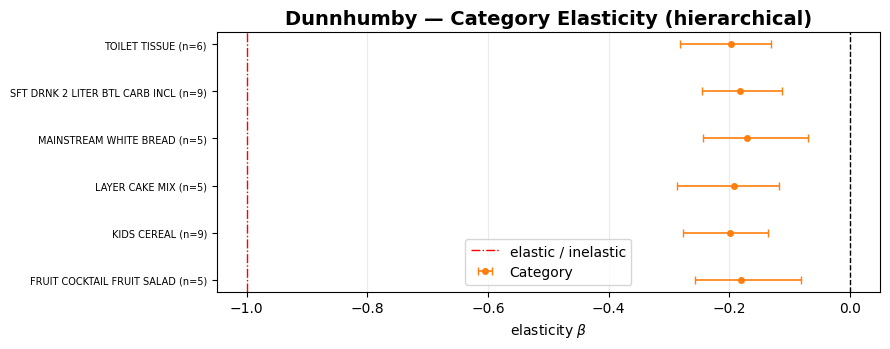

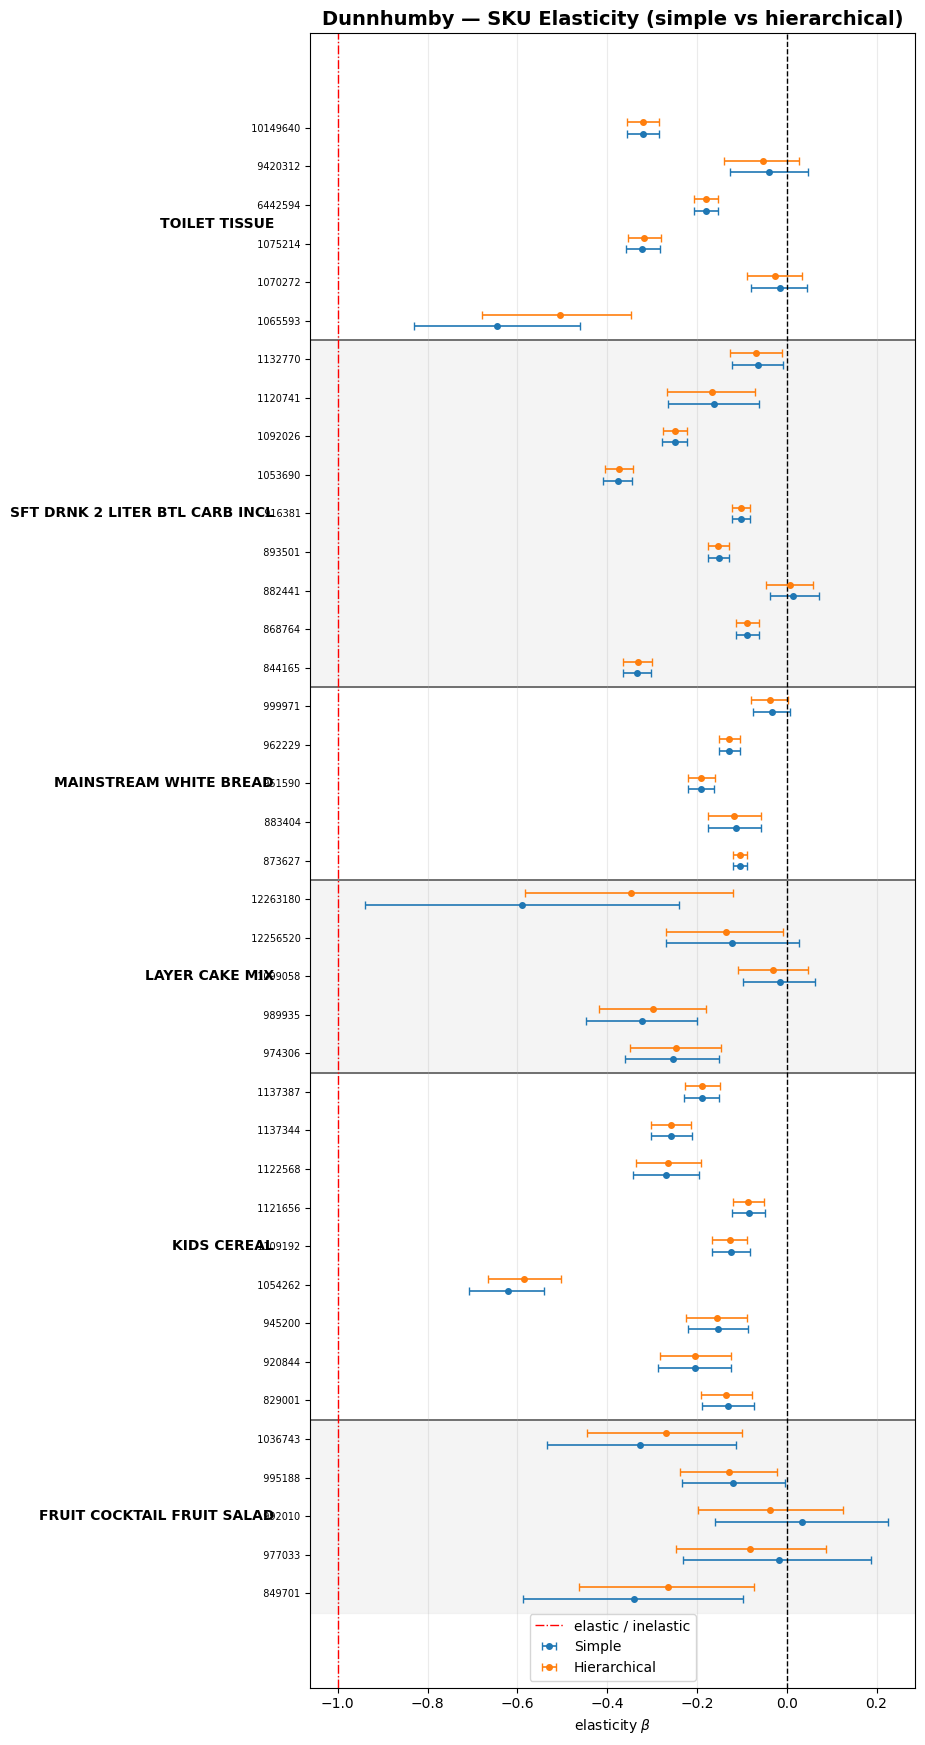

In [27]:
# get number of SKUs in each category
cat_n_skus = (
    dunnhumby_panel.groupby("sku_category")["sku"]
    .nunique()
    .reindex(cat_labels)
)
cat_tick_labels = [f"{cat} (n={int(cat_n_skus[cat])})" for cat in cat_labels]

# pooled category-level beta from the hierarchical model
fig, ax = plt.subplots(figsize=(9, max(3.0, 0.6 * len(cat_labels))))
y = plot_elasticity_forest(ax, beta_dh_cat, "Category", color="C1")
format_elasticity_forest(y, cat_tick_labels, "Dunnhumby — Category Elasticity (hierarchical)", False)

# simple vs hierarchical dodged comparison — overlay both models per SKU
fig, ax = plt.subplots(figsize=(10, max(5.0, 0.45 * len(sku_labels))))
add_category_forest_guides(ax, sku_to_cat_ord, cat_labels_arr)
y_dodge = 0.15
for spec, y_off, samples, color in [
    ("Simple", -y_dodge, beta_dh_simple, "C0"),
    ("Hierarchical", y_dodge, beta_dh_hier, "C1"),
]:
    s_ord = samples[:, order]
    yy = plot_elasticity_forest(ax, s_ord, spec, color=color, offset=y_off)

format_elasticity_forest(
    np.arange(len(sku_ord)), [f"  {s}" for s in sku_ord], 
    "Dunnhumby — SKU Elasticity (simple vs hierarchical)"
)

All category-level elasticities sit slightly below zero, which is reasonable for grocery necessities own-price response: higher shelf prices reduce quantity, but typically only modestly. On the SKU level, partial pooling changes the SKU elasticities in three ways compared with the simple model. Uncertainties shrink for products whose simple-model intervals were wide, because data-sparse SKUs borrow strength from better-observed neighbours in the same category. Implausible positive own-price elasticities are pulled below zero, toward the category mean. Shrinkage is selective: SKUs that sit far from their category, but with large uncertainty, move closer, while well-identified products — those with already tight intervals — keep nearly the same $\beta_s$.

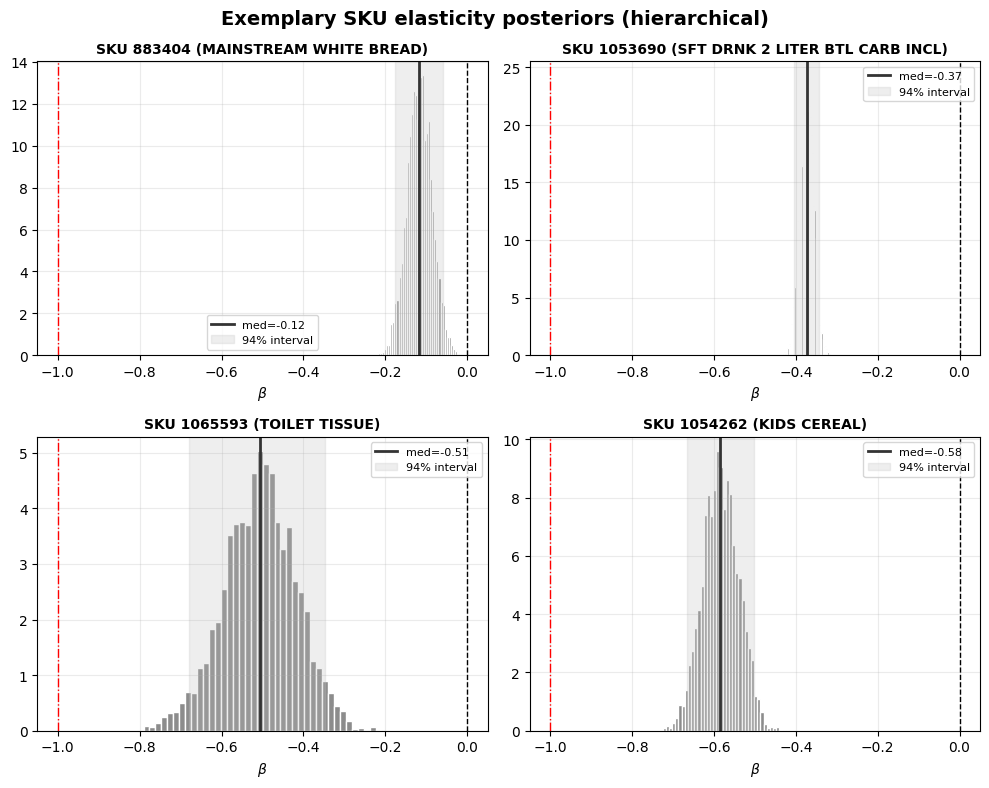

In [28]:
# select products with most sales, from difference categories if possible 
sku_sale_counts = (
    dunnhumby_panel.groupby(["sku", "sku_category"]).agg({"quantity": "sum"})
    .reset_index(level="sku_category")
    .sort_values(by=["sku_category", "quantity"], ascending=[True, False])
)
sku_sale_counts["row_number"] = sku_sale_counts.groupby("sku_category").cumcount() + 1
sku_sale_counts = sku_sale_counts.sort_values(by=["row_number", "quantity"], ascending=[True, False])
picked_skus = sku_sale_counts.index[0:4].tolist()

# 2x2 posterior histograms with 94% interval for exemplary SKUs
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for ax, sku in zip(axes, picked_skus):
    sku_pos = int(np.where(sku_labels == sku)[0][0])
    samples = beta_dh_hier[:, sku_pos]
    ax.hist(samples, bins=40, density=True, color="0.55", edgecolor="white")
    lo, med, hi = np.percentile(samples, [3, 50, 97])
    ax.axvline(med, color="0.2", linewidth=2, label=f"med={med:.2f}")
    ax.axvspan(lo, hi, alpha=0.25, color="0.75", label="94% interval")
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
    ax.axvline(-1.0, color="red", linestyle="-.", linewidth=1)
    cat = dunnhumby_panel.loc[dunnhumby_panel["sku"] == sku, "sku_category"].iloc[0]
    ax.set_title(f"SKU {sku} ({cat})", fontsize=10, fontweight="bold")
    ax.set_xlabel(r"$\beta$")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
plt.suptitle("Exemplary SKU elasticity posteriors (hierarchical)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The exemplary SKUs have unimodal, concentrated $\beta_s$ posteriors, with 94% intervals in a sensible range rather than piling up on a boundary or spreading across both large positive and large negative values.

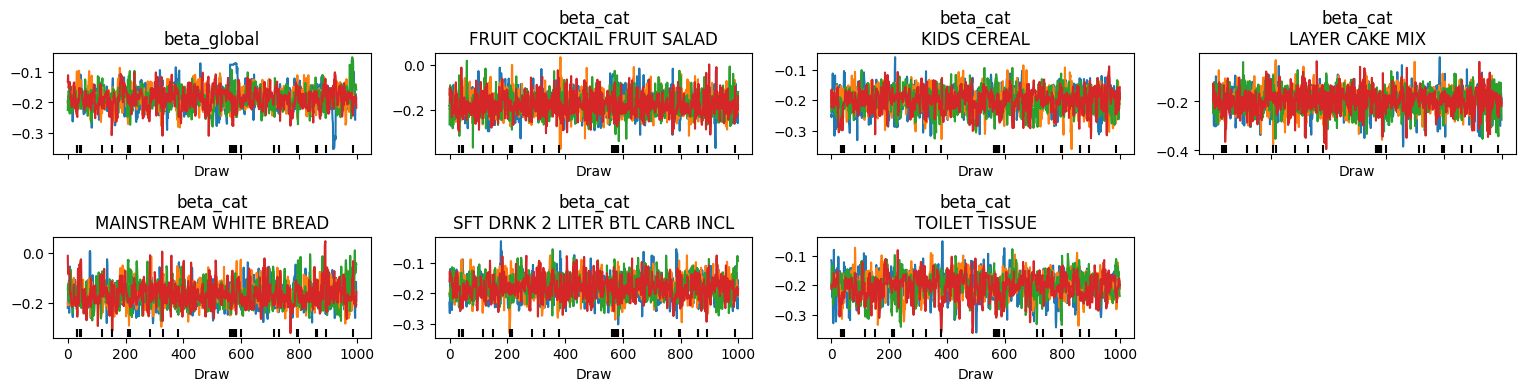

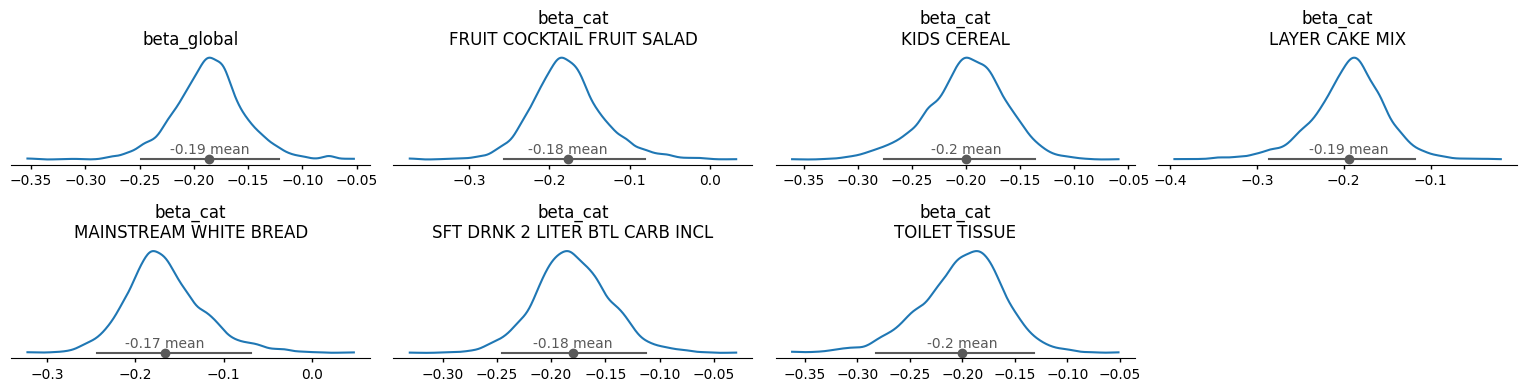

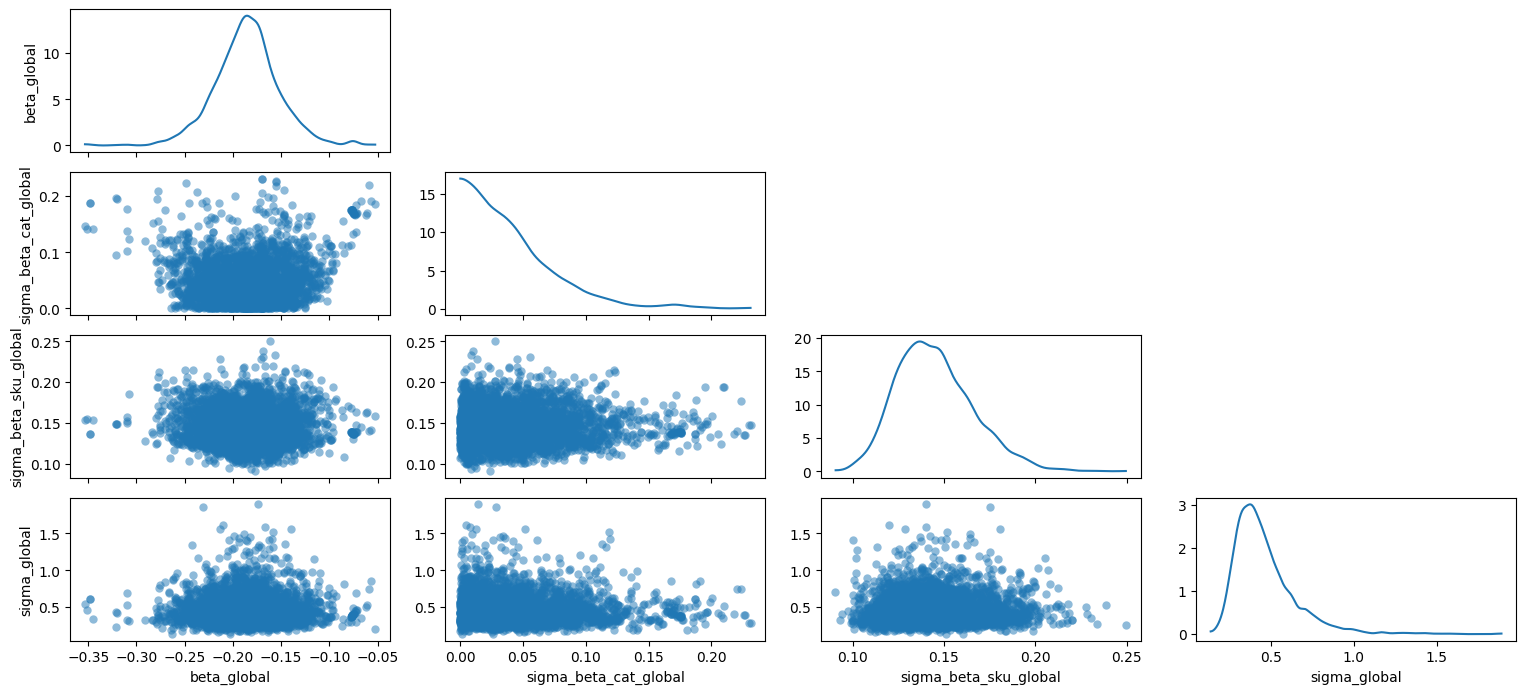

In [29]:
# plot some built-in diagnostics

# traces
az.plot_trace(
    dh_hier_idata,
    var_names=["beta_global", "beta_cat"],
)
plt.tight_layout()
plt.show()

# posteriors
az.plot_dist(
    dh_hier_idata,
    var_names=["beta_global", "beta_cat"],
    ci_prob=0.94,
)
plt.tight_layout()
plt.show()

# corner plot
az.plot_pair(
    dh_hier_idata,
    var_names=["beta_global", "sigma_beta_cat_global", "sigma_beta_sku_global", "sigma_global"],
    marginal=True, # 1D on diagonal
    triangle="lower", # lower triangle = 2D scatter/correlation
)
plt.tight_layout()
plt.show()